# Cars 4 You: Expending Car Evaluations with ML

## 1. Import the needed libraries

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from sklearn.feature_selection import mutual_info_regression
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import numpy as np
import os
from sklearn.metrics import make_scorer 
from sklearn.model_selection import PredefinedSplit


import numpy as np
import pandas as pd
import os
import random
from math import ceil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, KFold, PredefinedSplit, RandomizedSearchCV)
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, OrdinalEncoder)
from sklearn.impute import (SimpleImputer, KNNImputer)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import (RFE, RFECV, mutual_info_regression)
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, LogisticRegression)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, make_scorer)
from sklearn.base import clone
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import loguniform

## 2. Data importation and integration

In [2]:
train_data = pd.read_csv('project_data/train.csv')
test_data = pd.read_csv('project_data/test.csv')

In [3]:
data= train_data.copy()

## 3. Data exploration and understanding

### Metadata
- *carID*: An attribute that contains an identifier for each car.
- *Brand*: The car’s main brand (e.g. Ford, Toyota).
- *model*: The car model.
- *year*: The year of Registration of the Car.
- *mileage*: The total reported distance travelled by the car (in
 miles).
- *tax*: The amount of road tax (in £) that, in 2020, was
 applicable to the car in question.
- *fuelType*: Type of Fuel used by the car (Diesel, Petrol, Hybrid,
 Electric).
- *mpg*: Average Miles per Gallon.
- *engineSize*: Size of Engine in liters (Cubic Decimeters).
- *paintQuality%*:  The mechanic’s assessment of the cars’ overall paint
 quality and hull integrity (filled by the mechanic
 during evaluation). 
- *previousOwners*: Number of previous registered owners of the vehicle.
- *hasDamage*:  Boolean marker filled by the seller at the time of
 registration stating whether the car is damaged or
 not.
- *price*: The car’s price when purchased by Cars 4 You (in £).

### 3.1. Data Overview

In [ ]:
#overview the dataset
data.info()

In [ ]:
#first 20 rows
data.head(20)

In [ ]:
#last 20 rows
data.tail(20)

In [ ]:
#Descriptive statistics for numerical data
data.describe().T

In [ ]:
#Descriptive statistics for categorical data
data.describe(include = ['O'])

In [4]:
#separate numerical and categorical features 

metric_features = ['year', 'mileage', 'tax', 'mpg',
                    'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage']

non_metric_features= ['Brand','model','transmission','fuelType']

identifier = 'carID'

target = 'price'

In [ ]:
#checking what are the unique values of categorical variables
for col in non_metric_features:
    print(f"\nColumn: {col}")
    print(data[col].unique())

### 3.2. Checking Duplicates

In [ ]:
#Number of duplicates
data.duplicated().sum()

### 3.3. Checking Missing Values

In [ ]:
#Number of missing values
data.isna().sum()

In [ ]:
#Number of missing values in each column as a percentage
data.isna().sum()/len(data) * 100

### 3.4. Checking Outliers

In [5]:
# Checking outliers of numerical variables through the visualization of boxplots

def plot_multiple_boxplots(data, feats, title="Numeric Variables' Box Plots"):

    # Prepare figure. Create individual axes where each histogram will be placed
    fig, axes = plt.subplots(4, ceil(len(feats) / 4), figsize=(40, 30))

    # Plot data
    # Iterate across axes objects and associate each histogram:
    for ax, feat in zip(axes.flatten(), feats):
        sns.boxplot(x=data[feat], ax=ax, color="#5dade2")
        ax.set_title(feat)

    # Layout
    plt.suptitle(title)
    plt.show()

    return

In [ ]:
plot_multiple_boxplots(data, metric_features)

### 3.5. Checking Distributions

In [ ]:
df= pd.DataFrame(data[metric_features])

In [ ]:
# Creating histograms to see the distribrution of numerical variables

num_cols = df.select_dtypes(include=['number']).columns
n = len(num_cols)

# Adjust layout
fig, axes = plt.subplots(nrows=(n // 3) + 1, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='#5dade2', edgecolor='black')  
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('frequency')

# Remove empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3.5. Checking Categorical Variables

In [ ]:
# Creating barplots to understand the categorical data

sns.set_style('white')  
sns.set_palette(['#5dade2'])  

# Create 4 subplots stacked vertically
fig, ax = plt.subplots(nrows=4, ncols=1, dpi=300, figsize=(20, 40))
fig.patch.set_facecolor('white') 

# Plot each variable in its own row
sns.countplot(data=test_data, x='Brand', ax=ax[0])
sns.countplot(data=test_data, x='model', ax=ax[1])
sns.countplot(data=test_data, x='transmission', ax=ax[2])
sns.countplot(data=test_data, x='fuelType', ax=ax[3])

# Improve spacing between plots
plt.tight_layout()
plt.show()

### 3.6. Checking Correlation between Variables

In [ ]:
# Check correlation between variables 
# We are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = data[metric_features].corr(method ='spearman')
cor_spearman

In [ ]:
# Create correlation matrix to facilitate interpretation

def cor_heatmap(cor):
    plt.figure(figsize=(12, 10))

    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(cor, dtype=bool))

    # Plot heatmap 
    sns.heatmap(
        data=cor,
        mask=mask,
        annot=True,
        cmap='YlGnBu',   
        fmt='.2f',
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )

    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

In [ ]:
cor_heatmap(cor_spearman)

In [ ]:
# Pairwise Relationship of Numerical Variables
sns.set()

# Setting pairplot and use historgrams in the diagonal
sns.pairplot(df[metric_features], diag_kind="hist")

# Layout
plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)

# Create eda directory 
if not os.path.exists(os.path.join('..', 'figures', 'eda')):
    os.makedirs(os.path.join('..', 'figures', 'eda'))
    
plt.savefig(os.path.join('..', 'figures', 'eda', 'pairwise_numeric_scatterplots.png'), dpi=200)
plt.show()

## 4. Data preparation

### 4.1. Set index

In [4]:
# Set index to CarID as each car has its own unique identifier
data.set_index('carID', inplace = True)
test_data.set_index('carID', inplace = True)

### 4.2. Slipt the data into train and validation dataset

#### The Hold Out Method

In [5]:
X = data.drop('price', axis = 1) # In X, the target variable will be removed and the dataset will be used as the training set
y = data['price']  # y corresponds to the target variable

In [6]:
# Splits the dataset

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3,  # 30% will be used for validation 
                                                  random_state = 0,      # Ensures the split is always the same every time the code runs
                                                  shuffle = True)        # Shuffles the data before spliting to avoid bias

### 4.3. Changing datatypes

In [7]:
# Rounds the floats and changes them to integers

#year to integer
X_train['year'] = X_train['year'].round().astype('Int32')
X_val['year'] = X_val['year'].round().astype('Int32')
test_data['year'] = test_data['year'].round().astype('Int32')

#previousOwners to integer
X_train['previousOwners'] = X_train['previousOwners'].round().astype('Int32')
X_val['previousOwners'] = X_val['previousOwners'].round().astype('Int32')
test_data['previousOwners'] = test_data['previousOwners'].round().astype('Int32')

#hasDamaged to boolean
X_train['hasDamage'] = X_train['hasDamage'].astype('Int8')
X_val['hasDamage'] = X_val['hasDamage'].astype('Int8')
test_data['hasDamage'] = test_data['hasDamage'].astype('Int8')

In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53181 entries, 42520 to 15659
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           52128 non-null  object 
 1   model           52136 non-null  object 
 2   year            52130 non-null  Int32  
 3   transmission    52086 non-null  object 
 4   mileage         52157 non-null  float64
 5   fuelType        52160 non-null  object 
 6   tax             47671 non-null  float64
 7   mpg             47683 non-null  float64
 8   engineSize      52118 non-null  float64
 9   paintQuality%   52091 non-null  float64
 10  previousOwners  52090 non-null  Int32  
 11  hasDamage       52087 non-null  Int8   
dtypes: Int32(2), Int8(1), float64(5), object(4)
memory usage: 4.7+ MB


### 4.4. Handling Incoherencies

#### 4.4.1. Categorical Variables 

##### 4.4.1.1. Correcting Spelling Mistakes

In [9]:
#correcting spelling mistakes of 'brand' for X_train, X_val and test_data

correct_brand = {
    'VW': ['V', 'vw', 'v', 'W', 'w'],
    'Toyota': ['Toyot', 'TOYOTA', 'oyota', 'toyota', 'OYOTA', 'TOYOT', 'toyot', 'oyot'],
    'Audi': ['udi', 'AUDI', 'audi', 'Aud', 'aud', 'UDI', 'AUD'],
    'Ford': ['FOR', 'ord', 'For', 'FORD', 'ford', 'for', 'or', 'ORD'],
    'BMW': ['MW', 'bmw', 'BM', 'mw', 'M', 'bm'],
    'Skoda': ['koda', 'skoda', 'SKODA', 'Skod', 'kod', 'SKOD', 'KODA', 'skod'],
    'Opel': ['Ope', 'opel', 'pel', 'pe', 'OPEL', 'PEL', 'OPE', 'ope'],
    'Mercedes': ['mercedes', 'Mercede', 'MERCEDES', 'ercedes', 'mercede', 'ERCEDES', 'ercede', 'MERCEDE'],
    'Hyundai': ['yundai', 'Hyunda', 'hyundai', 'HYUNDAI', 'yunda', 'HYUNDA', 'ud', 'hyunda', 'YUNDAI']
}

# Create a reverse lookup dictionary (each incorrect form maps to the correct one)
replacement_dict = {variant: correct for correct, variants in correct_brand.items() for variant in variants}

# Replace incorrect brand names with the correct ones
X_train["Brand"] = X_train["Brand"].replace(replacement_dict)
X_val["Brand"] = X_val["Brand"].replace(replacement_dict)
test_data["Brand"] = test_data["Brand"].replace(replacement_dict)

# Verify the cleaning
print(X_train["Brand"].unique())
print(X_val["Brand"].unique())
print(test_data["Brand"].unique())

['Mercedes' 'Ford' 'Hyundai' 'VW' 'Opel' 'Audi' 'Toyota' 'BMW' nan 'Skoda']
['Mercedes' 'Opel' 'Ford' 'VW' 'Toyota' nan 'BMW' 'Skoda' 'Audi' 'Hyundai']
['Hyundai' 'VW' 'BMW' 'Opel' 'Ford' 'Mercedes' 'Skoda' 'Toyota' 'Audi' nan]


In [10]:
##correcting spelling mistakes of 'model' for X_train, X_val and test_data

correct_model = {
    'Golf': [' GOLF', ' Gol', ' golf', 'golf', ' Golf', ' gol', ' GOL', 'Gol', 'GOLF'],
    'Yaris': [' Yaris', ' YARIS', ' Yari', ' yaris', ' yari', 'Yari', ' YARI', 'yaris', 'YARIS'],
    'Q2': [' q2', ' Q2'],
    '2 Series': [' 2 series', ' 2 serie', '2 Series', ' 2 SERIES', ' 2 Serie', '2 Serie', ' 2 Series'],
    '3 Series': [' 3 Series', ' 3 Serie', ' 3 series', ' 3 SERIES', ' 3 serie', '3 Serie'],
    'A3': [' A3', ' a3'],
    'Octavia': [' Octavi', ' OCTAVIA', ' Octavia', ' octavia', 'Octavi', 'octavia', ' octavi', ' OCTAVI'],
    'Passat': [' PASSAT', ' passat', ' Passa', 'Passat', ' Passat', 'PASSAT', ' PASSA'],
    'Insignia': [' Insigni', ' INSIGNIA', ' insignia', ' Insignia', ' INSIGNI', 'Insigni'],
    'Fabia': [' Fabia', ' fabia', ' FABIA', ' Fabi', 'FABIA'],
    'A Class': [' A Clas', ' A Class', ' a class', ' A CLASS', 'a class', 'A CLASS', ' a clas'],
    'Ka+': [' Ka+', ' KA+', ' ka+', 'ka+'],
    'GLC Class': [' GLC Class', ' GLC CLASS', ' GLC Clas', ' glc class', ' glc clas'], 
    'I30': [' i30', ' I30'],
    'C Class': [' C Clas', ' C CLASS', ' c class', 'C Clas', ' C CLAS', 'c class', ' c clas', ' C Class', 'C CLASS'],
    'Polo': [' POLO', ' Polo', ' polo', ' Pol', ' POL', 'Pol', 'POLO'],
    'E Class': [' E Class', ' E Clas', ' E CLASS', ' e class', 'E CLASS', 'e class'],
    'Q5': [' Q5', ' q5', 'q5'],
    'Up': ['U', ' up', ' UP', ' Up', ' U', 'UP'],
    'Fiesta': [' FIESTA', ' fiesta', ' Fiest', ' Fiesta', 'fiesta', 'Fiest', ' FIESTA', 'FIESTA', ' fiest'],
    'C-HR': [' C-H', ' c-hr', ' C-HR', ' c-h'],
    'Mokka X': [' mokka x', ' MOKKA X', ' Mokka X'],
    'Corsa': [' Corsa', ' corsa', ' Cors', ' CORSA', ' cors', ' CORS', 'corsa'],
    'Astra': [' ASTRA', ' Astr', ' Astra', ' astra', 'ASTRA', 'astra'],
    'TT': [' tt', ' TT', ' T'],
    '5 Series': [' 5 Series', ' 5 Serie', ' 5 SERIES', ' 5 series', '5 SERIES', ' 5 SERIE'],
    'Aygo': [' aygo', ' ayg', ' AYGO', ' Ayg', ' Aygo', 'aygo', ' AYG'],
    '4 Series': [' 4 SERIES', ' 4 Serie', ' 4 serie', '4 series', '4 Series', ' 4 Series', ' 4 series'],
    'SLK': [' slk', ' SLK'],
    'Viva': [' viva', ' Viva', ' VIVA', ' Viv', 'viva'],
    'Focus': [' Focus', ' Focu', ' FOCUS', ' focus', ' FOCU', 'focus', 'Focu', ' focu', 'FOCUS'],
    'EcoSport': [' EcoSpor', ' ECOSPORT', ' ecosport', ' EcoSport'],
    'X-CLASS': [' x-clas', ' X-CLAS', ' x-class', ' X-CLASS'],
    'CL Class': [' cl class', ' CL Clas', ' CL CLASS', ' CL Class'],
    'IX20': [' ix20', ' IX20'],
    'Rapid': [' Rapi', ' rapid', ' Rapid'],
    'Auris': [' Auris', ' AURIS', ' auris', ' Auri'],
    'I20': [' i20', ' I20'],
    'X3': [' x3', ' X3'],
    'A8': [' A8', 'a8'],
    'GLS Class': [' GLS Clas', ' GLS CLASS', ' gls class', ' GLS Class'],
    'B-MAX': [' B-MA', ' B-MAX', 'B-MA', ' b-max'],
    'A4': [' A4', ' a4'],
    'Kona': [' KONA', ' Kon', ' Kona', ' KON', ' kona'],
    'I10': [' i10', ' I10'],
    'A1': [' A1', ' a1'],
    'Mokka': [' Mokka ', ' Mokk', ' Mokka', ' mokka ', ' mokka', ' MOKKA', 'Mokka ', 'Mokk'],
    'S-MAX': [' S-MA', ' s-max', ' S-MAX', ' s-ma'],
    'X2': [' x2', ' X2'],
    'Crossland X': [' crossland x', ' CROSSLAND X', ' Crossland X'],
    'Tiguan': [' Tiguan', ' tiguan', ' Tigua', ' TIGUAN', ' TIGUA', 'Tigua', 'TIGUAN', 'tiguan', ' tigua'],
    'A5': [' A5', ' a5', 'a5'],
    'GLE Class': [' GLE Clas', ' GLE Class', ' gle class', ' GLE CLASS'],
    'Zafira': [' Zafira', ' Zafir', ' ZAFIRA', ' zafira', 'Zafir', ' ZAFIR'],
    'Ioniq': [' Ioni', ' Ioniq', ' IONIQ', 'IONIQ', ' ioniq'],
    'A6': [' A6', ' a6'],
    'Yeti Outdoor': [' yeti outdoor', ' Yeti Outdoor', ' YETI OUTDOOR', ' Yeti Outdoo', ' yeti outdoor', 'yeti outdoor', ' yeti outdoo'],
    'X1': [' x1', 'x1', ' X1'],
    'Scala': [' SCALA', ' Scala', ' scala', ' Scal', ' scal'],
    'S Class': [' S Class', ' S Clas', ' s class', ' S CLASS'],
    '1 Series': [' 1 Series', ' 1 SERIES', ' 1 Serie', ' 1 series', '1 SERIES', ' 1 SERIE', '1 series', ' 1 serie'],
    'Kamiq': [' KAMIQ', ' KAMI', ' kamiq', ' Kamiq'],
    'Kuga': [' Kug', ' KUGA', ' kuga', 'Kuga', ' Kuga', 'kuga'],
    'Tourneo Connect': [' tourneo connect', ' Tourneo Connect'],
    'Q7': [' q7', ' Q7'],
    'GLA Class': [' GLA Class', ' GLA CLASS', ' GLA Clas', ' gla class'],
    'Arteon': [' arteon', ' Arteon', ' Arteon'],
    'SL CLASS': [' SL CLAS', ' SL CLASS', ' sl class', ' SL'],
    'Tucson': [' Tucson', ' TUCSON', ' Tucso', ' tucson', ' TUCSO', 'Tucso'],
    'Santa Fe': [' Santa F', ' santa fe', ' SANTA FE', ' Santa Fe'],
    'Grandland X': [' Grandland X', ' grandland x', ' GRANDLAND X'],
    'RAV4': [' rav4', 'RAV4', 'RAV', ' RAV', 'rav4', ' rav', ' RAV4'],
    'Touran': [' Touran', 'Toura', ' TOURAN', ' touran', ' Toura', ' TOURA'],
    'Citigo': [' Citig', ' citigo', ' Citigo', ' CITIGO', 'CITIGO'],
    'Roomster': [' Roomste', ' Roomster'],
    'Prius': [' PRIUS', ' Prius', 'Prius', ' prius'],
    'Corolla': [' corolla', ' COROLLA', ' Coroll', ' Corolla', 'corolla'],
    'B Class': [' b class', ' B Clas', ' B Class', ' B CLASS', 'b class'],
    'Sharan': [' sharan', ' Shara', ' Sharan', ' SHARAN'],
    'Kodiaq': [' Kodia', ' kodiaq', 'kodiaq', ' KODIAQ', ' Kodiaq'],
    'V Class': [' V Clas', ' V CLASS', ' V Class', ' v class'],
    'Caddy Maxi Life': [' Caddy Maxi Lif', ' Caddy Maxi Life'],
    'Superb': [' Superb', ' Super', ' SUPERB', ' superb', ' super'],
    'T-Roc': [' T-Roc', ' T-RO', ' t-roc', ' T-Ro', ' T-ROC'],
    'Combo Life': [' COMBO LIFE', ' combo life', ' Combo Lif', 'COMBO LIFE', ' Combo Life'],
    'Beetle': [' Beetl', ' Beetle', ' beetle'],
    'Galaxy': [' GALAXY', ' Galax', ' galaxy', ' Galaxy'],
    'M3': [' M3', ' m3'],
    'Gtc': [' gtc', ' GTC', ' gtc', 'gtc', 'GTC'],
    'X4': [' X4', ' x4'],
    'KA': [' Ka', ' ka', ' K', ' KA'],
    'IX35': [' ix35', ' IX35'],
    'Grand Tourneo Connect': [' Grand Tourneo Connec', ' Grand Tourneo Connect'],
    'M4': [' m4', ' M4'],
    'Tourneo Custom': [' tourneo custom', ' Tourneo Custo', ' Tourneo Custom'],
    'Z4': [' Z4', ' z4'],
    'X5': [' X5', ' x5'],
    'Meriva': [' Meriva', ' MERIVA', ' Meriv', ' meriva'],
    'RS6': [' RS6'],
    'Verso': [' VERSO', ' verso', ' Verso', ' Vers'],
    'Touareg': [' Touareg', ' TOUAREG', ' touareg', ' Touare'],
    'Mondeo': [' MONDEO', ' Mondeo', ' mondeo', ' MONDE', ' Monde'],
    'Shuttle': [' shuttle', ' Shuttle', ' SHUTTLE'],
    'CLS Class': [' CLS Class', ' cls class', ' CLS Clas', ' CLS CLASS'], 
    'C-MAX': [' C-MAX', ' c-max', ' C-MA'],
    'Puma': [' puma', ' PUMA', ' Puma', 'Pum', ' Pum'],
    'CLA Class': [' CLA Class', ' CLA CLASS', ' cla class', ' CLA Clas'],
    'I40': [' I40', ' i40'],
    'Q3': [' q3', ' Q3'],
    'Tiguan Allspace': [' TIGUAN ALLSPACE', ' tiguan allspace', ' Tiguan Allspac', ' Tiguan Allspace'],
    '6 Series': [' 6 SERIES', ' 6 series', ' 6 Series', ' 6 Serie'],
    'Caravelle': [' caravelle', ' Caravell', ' Caravelle'],
    'Karoq': [' Karoq', ' karoq', ' KAROQ', ' Karo'],
    'I3': [' i3', 'i3', ' I3'],
    'Grand C-MAX': [' GRAND C-MAX', ' grand c-max', ' Grand C-MA', ' Grand C-MAX'],
    'T-Cross': [' T-Cros', ' T-CROSS', ' T-Cross', ' t-cros', ' t-cross'],
    'A7': [' a7', ' A7'],
    'Golf SV': [' Golf SV', ' golf sv', ' GOLF SV'],
    'A': [' a', ' A'],
    'GT86': [' gt86', ' GT86'],
    'Yeti': [' yeti', ' Yet', ' Yeti', ' YETI'],
    'X': [' x', ' X'],
    'Land Cruiser': [' Land Cruise', ' Land Cruiser', ' land cruiser'],
    'EDGE': [' Edge', ' edge', ' Edg', ' EDGE'],
    'X6': [' X6'],
    'Fusion': [' Fusion', ' fusion'],
    'GL Class': [' GL CLASS', ' gl class', ' GL Class', ' GL Clas'],
    'Scirocco': [' scirocco', ' SCIROCCO', ' Scirocc', ' Scirocco'],
    'Z3': [' Z3'],
    'Hilux': [' hilux', ' Hilux', ' Hilu', ' HILU'],
    'Amarok': [' amarok', ' Amarok', ' Amaro'],
    'CC': [' cc', ' CC'],
    '7 Series': [' 7 Serie', ' 7 SERIES', ' 7 series', ' 7 Series'],
    'Avensis': [' AVENSIS', ' avensis', ' Avensis'],
    'M Class': [' m class', ' M CLASS', ' M Class', ' M Clas', ' M CLAS'],
    'Grandland': [' grandland ', ' Grandland '],
    'Zafira Tourer': [' Zafira Toure', ' ZAFIRA TOURER', ' Zafira Tourer', ' zafira tourer'],
    'R8': [' R8', ' r8'],
    'Mustang': [' mustang', ' Mustang'],
    'Q8': [' Q8'],
    'CLK': [' CLK'],
    'RS3': [' RS3'],
    'Jetta': [' JETTA', ' Jetta', ' jetta', 'Jetta' ],
    'Supra': [' Supra'],
    'X7': [' X7'],
    'SQ7': [' SQ7', ' sq7'],
    'S3': [' s3', ' S3'],
    'Arteon': [' Arteo', 'Arteo', ' ARTEON', ' arteon', ' Arteon'],
    'GLB Class': [' glb class', ' GLB Class'],
    'Adam': [' Ada', ' adam', ' ADAM', ' Adam'],
    'M5': [' M5',' m5'],
    'Golf S': [' golf s', ' Golf S'],
    'Vectra': ['Vectra', ' Vectra', ' VECTRA', 'VECTRA'],
    '8 Series': [' 8 SERIES', ' 8 Serie', ' 8 Series', ' 8 series'],
    'Urban Cruiser': [' Urban Cruise', ' Urban Cruiser'],
    'Fox': ['fox', ' fox', ' Fox'], 
    'Q': [' Q'], 
    'M2': [' M2'], 
    'RS4':[' RS4'], 
    'Veloster': [' Veloster', ' Veloste'],  
    'IQ': [' IQ'], 
    'Agila': [' AGILA', ' Agila'], 
    'I2': [' I2'], 
    'Antara': [' Antara', ' antara'], 
    'G Class': [' G Class', ' G CLAS'], 
    'Caddy Life': [' Caddy Life', ' Caddy'],
    'R Class': [' R Class'], 
    'I800': [' I800'],
    'Amica': [' Amica'], 
    'Crossland': [' Crossland '],
    'Proace Verso': [' proace verso', ' PROACE VERSO', 'PROACE VERSO'],
    'Camry': [' Camry', 'Camry', ' Camr'], 
    'Tigra': [' Tigra'], 
    'Eos': [' Eos'], 
    'M': [' M'],
    'California': [' Californi', ' California'], 
    'Ampera': [' Ampera'], 
    'I1': [' I1'], 
    'S5': [' S5'], 
    'CLC Class': [' CLC Class'], 
    'Shara': [' SHARA'], 
    'I8': [' i8', 'i8'], 
    'RS7': [' RS7'], 
    'Transit Tourneo': [' Transit Tourneo'], 
    'I4': [' I4'], 
    'S4':[' S4'], 
    'Terracan': [' Terracan'], 
    'Cascada': [' Cascada'], 
    'S8': [' S8'], 
    'A2':[' A2'], 
    'Vivaro':[' Vivaro'],
    'RS5':[' RS5'],
    'SQ5':[' SQ5'], 
    'Getz':[' Getz'], 
    'M6':[' M6'], 
    'Caddy Maxi': [' Caddy Maxi'], 
    'Z':[' Z'], 
    'Verso-S': [' Verso-S'], 
    'Kadjar': [' Kadjar'], 
    'I80': [' I80'], 
    'Streetka': [' Streetka'],
    'RS': [' RS'], 
    'I': [' i'], 
    'Ranger': [' Ranger'], 
    'IX2': [' IX2'], 
    'Escort': [' Escort'],
    'Accent': [' Accent']
}


# Create a reverse lookup dictionary (each incorrect form maps to the correct one)
replacement_dict = {variant: correct for correct, variants in correct_model.items() for variant in variants}

# Replace incorrect brand names with the correct ones
X_train["model"] = X_train["model"].replace(replacement_dict)
X_val["model"] = X_val["model"].replace(replacement_dict)
test_data["model"] = test_data["model"].replace(replacement_dict)

# Verify the cleaning
print(X_train["model"].unique())
print(X_val["model"].unique())
print(test_data["model"].unique())

['E Class' 'Focus' 'C Class' 'IX20' 'Golf' 'I10' 'T-Cross' 'Corsa' 'A4'
 'Polo' 'Tucson' 'Kuga' 'Corolla' 'Yaris' 'Q3' 'A Class' 'A1' 'A5' 'Q5'
 'GLE Class' '3 Series' 'Fiesta' 'T-Roc' 'Insignia' 'GLC Class' 'X1'
 'Astra' 'Q2' 'Aygo' 'C-MAX' 'Q' '2 Series' 'A3' 'Touran' 'TT' 'Santa Fe'
 'C-HR' 'Superb' 'EDGE' 'S Class' 'CL Class' 'Ka+' 'Octavia' 'Arteon' 'X4'
 'Z4' nan 'EcoSport' 'Yeti Outdoor' 'Meriva' 'I20' 'Hilux' 'X5' 'M4'
 'CLA Class' '1 Series' 'Mokka X' 'Prius' 'X2' '4 Series' 'S4' 'Fabia'
 'Auris' 'Galaxy' 'Citigo' 'A6' 'RAV4' 'Passat' 'Grand C-MAX' 'Adam'
 'GLA Class' 'G Class' 'Zafira' 'Touareg' 'Sharan' 'Mokka' 'Tiguan'
 'Ioniq' 'Q7' 'Viva' 'X3' 'Tiguan Allspace' 'B Class' 'Up' 'Crossland X'
 'CLS Class' 'SLK' 'Kodiaq' 'Mondeo' 'B-MAX' 'Caddy Life' 'SL CLASS' 'A7'
 'A' 'I30' 'Yeti' 'Grandland X' 'Tourneo Custom' 'Antara' 'Avensis' 'X6'
 '5 Series' 'GL Class' 'IX35' 'Kamiq' 'KA' 'Caravelle' 'Karoq' 'Scala'
 'V Class' 'Golf SV' 'Verso' 'Kona' '7 Series' '6 Series' 'SQ7' 'Golf 

In [11]:
##correcting spelling mistakes of 'transmission' for X_train, X_val and test_data

correct_transmission = {
    'Semi-Auto': ['Semi-Aut', 'semi-auto', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT', 'EMI-AUTO', 'emi-Aut', 'emi-auto', 'semi-aut'],
    'Manual': ['anual', 'manual', 'Manua', 'MANUAL', ' Manual ', 'ANUAL', 'manua', 'anua', 'MANUA', ' manual ', ' MANUAL ', ' Manual', 'Manual ', 'manual '],
    'Automatic': ['AUTOMATIC', 'automatic', 'Automati', 'utomatic', 'UTOMATIC', 'automati', 'AUTOMATI', 'utomati'],
}

# Create a reverse lookup dictionary (each incorrect form maps to the correct one)
replacement_dict = {variant: correct for correct, variants in correct_transmission.items() for variant in variants}

# Replace incorrect brand names with the correct ones
X_train["transmission"] = X_train["transmission"].replace(replacement_dict)
X_val["transmission"] = X_val["transmission"].replace(replacement_dict)
test_data["transmission"] = test_data["transmission"].replace(replacement_dict)

#replacing the 'unknown' and 'other' variable with a missing value
X_train["transmission"] = X_train["transmission"].replace(['unknow','UNKNOWN','nknown','nknow', 'unknown', 'Other'], np.nan)
X_val["transmission"] = X_val["transmission"].replace(['unknow','UNKNOWN','nknown','nknow', 'unknown', 'Other'], np.nan)
test_data["transmission"] = test_data["transmission"].replace(['unknow','UNKNOWN','nknown','nknow', 'unknown', 'Other'], np.nan)

# Verify the cleaning
print(X_train["transmission"].unique())
print(X_val["transmission"].unique())
print(test_data["transmission"].unique())

['Semi-Auto' 'Automatic' 'Manual' nan]
['Semi-Auto' 'Manual' nan 'Automatic']
['Automatic' 'Semi-Auto' 'Manual' nan]


In [12]:
##correcting spelling mistakes of 'fuelType' for X_train, X_val and test_data

correct_fuelType = {
    'Petrol': ['etrol', 'petrol', 'PETROL', 'Petro', 'petro', 'ETROL', 'PETRO', 'etro', 'ETRO'],
    'Diesel': ['diesel','iesel','Diese','DIESEL','DIESE','IESEL','iese','diese','IESE'],
    'Hybrid': ['HYBRID','ybri','Hybri','ybrid','hybrid','YBRID','HYBRI', 'hybri'],
    'Other': ['ther','Othe','OTHER','other']
}

# Create a reverse lookup dictionary (each incorrect form maps to the correct one)
replacement_dict = {variant: correct for correct, variants in correct_fuelType.items() for variant in variants}

# Replace incorrect brand names with the correct ones
X_train["fuelType"] = X_train["fuelType"].replace(replacement_dict)
X_val["fuelType"] = X_val["fuelType"].replace(replacement_dict)
test_data["fuelType"] = test_data["fuelType"].replace(replacement_dict)

#replacing the 'other' variable with a missing value 
X_train["fuelType"] = X_train["fuelType"].replace(['ther','Othe','OTHER','other', 'Other'], np.nan)
X_val["fuelType"] = X_val["fuelType"].replace(['ther','Othe','OTHER','other', 'Other'], np.nan)
test_data["fuelType"] = test_data["fuelType"].replace(['ther','Othe','OTHER','other', 'Other'], np.nan)

# Verify the cleaning
print(X_train["fuelType"].unique())
print(X_val["fuelType"].unique())
print(test_data["fuelType"].unique())

['Diesel' 'Petrol' 'Hybrid' nan 'Electric']
['Diesel' 'Petrol' nan 'Hybrid']
['Petrol' 'Diesel' 'Hybrid' nan 'Electric']


##### 4.4.1.2. Check if the Models correspond to the Brand

**Audi**

In [13]:
#Check the models of Audi for X_train
audi = X_train[X_train['Brand'].str.lower() == 'audi']
unique_audi_models = sorted(audi['model'].dropna().unique())
unique_audi_models

['A',
 'A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'Q',
 'Q2',
 'Q3',
 'Q5',
 'Q7',
 'Q8',
 'R8',
 'RS',
 'RS3',
 'RS4',
 'RS5',
 'RS6',
 'S3',
 'S4',
 'S8',
 'SQ5',
 'SQ7',
 'TT']

In [14]:
#Check the models of Audi for X_val
audi = X_val[X_val['Brand'].str.lower() == 'audi']
unique_audi_models_v = sorted(audi['model'].dropna().unique())
unique_audi_models_v

['A',
 'A1',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'Q',
 'Q2',
 'Q3',
 'Q5',
 'Q7',
 'Q8',
 'R8',
 'RS3',
 'RS4',
 'RS5',
 'RS6',
 'S3',
 'S4',
 'S5',
 'S8',
 'SQ5',
 'SQ7',
 'TT']

In [15]:
#Check the models of Audi for test_data
audi = test_data[test_data['Brand'].str.lower() == 'audi']
unique_audi_models = sorted(audi['model'].dropna().unique())
unique_audi_models

['A',
 'A1',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'Q',
 'Q2',
 'Q3',
 'Q5',
 'Q7',
 'Q8',
 'R8',
 'RS3',
 'RS4',
 'RS5',
 'RS6',
 'RS7',
 'S3',
 'S4',
 'S5',
 'SQ5',
 'SQ7',
 'TT']

- All models seem to correspond to Audi cars, except for models 'A' and 'Q'. There are no models in Audi that are named 'A' and 'Q' solely, normally there are followed by a number, for example, 'A1' or 'Q3' as seen in the dataset. 
- Since it might be a problem of data collection, in a way that is missing a number after the letter, we have decided to replace these values by missing values. 

In [16]:
#replacing model 'A' by missing values
X_train.loc[X_train["model"] == 'A', "model"] = np.nan
X_val.loc[X_val["model"] == 'A', "model"] = np.nan
test_data.loc[test_data["model"] == 'A', "model"] = np.nan

In [17]:
#replacing model 'Q' by missing values
X_train.loc[X_train["model"] == 'Q', "model"] = np.nan
X_val.loc[X_val["model"] == 'Q', "model"] = np.nan
test_data.loc[test_data["model"] == 'Q', "model"] = np.nan

**BMW**

In [18]:
#Check the models of 'BMW' for X_train
BMW = X_train[X_train['Brand'].str.lower() == 'bmw']
unique_bmw_models = sorted(BMW['model'].dropna().unique())
unique_bmw_models

['1 Series',
 '2 Series',
 '3 Series',
 '4 Series',
 '5 Series',
 '6 Series',
 '7 Series',
 '8 Series',
 'I',
 'I3',
 'I8',
 'M',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'X',
 'X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'Z',
 'Z3',
 'Z4']

In [19]:
#Check the models of 'BMW' for X_val
BMW = X_val[X_val['Brand'].str.lower() == 'bmw']
unique_bmw_models_v = sorted(BMW['model'].dropna().unique())
unique_bmw_models_v

['1 Series',
 '2 Series',
 '3 Series',
 '4 Series',
 '5 Series',
 '6 Series',
 '7 Series',
 '8 Series',
 'I3',
 'I8',
 'M',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'X',
 'X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'Z3',
 'Z4']

In [20]:
#Check the models of 'BMW' for test_data
BMW = test_data[test_data['Brand'].str.lower() == 'bmw']
unique_bmw_models = sorted(BMW['model'].dropna().unique())
unique_bmw_models

['1 Series',
 '2 Series',
 '2 series',
 '3 Series',
 '4 Series',
 '5 Series',
 '6 Series',
 '7 Series',
 '8 Series',
 'I3',
 'I8',
 'M',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'X',
 'X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'Z3',
 'Z4']

- Similarly to 'Audi', in 'BMW' there are also models that should be followed by a number, which are 'X', 'Z', 'I' and 'M'.
- Therefore, we are going to replace it by missing values, for the same reason. 

In [21]:
#replacing model 'X' by missing values
X_train.loc[X_train["model"] == 'X', "model"] = np.nan
X_val.loc[X_val["model"] == 'X', "model"] = np.nan
test_data.loc[test_data["model"] == 'X', "model"] = np.nan

In [22]:
#replacing model 'Z' by missing values
X_train.loc[X_train["model"] == 'Z', "model"] = np.nan

In [23]:
#replacing model 'I' by missing values
X_train.loc[X_train["model"] == 'I', "model"] = np.nan

In [24]:
#replacing model 'M' by missing values
X_train.loc[X_train["model"] == 'M', "model"] = np.nan
X_val.loc[X_val["model"] == 'M', "model"] = np.nan
test_data.loc[test_data["model"] == 'M', "model"] = np.nan

**Ford**

In [25]:
#Check the models of 'Ford' for X_train
Ford = X_train[X_train['Brand'].str.lower() == 'ford']
unique_ford_models = sorted(Ford['model'].dropna().unique())
unique_ford_models

['B-MAX',
 'C-MAX',
 'EDGE',
 'EcoSport',
 'Escort',
 'Fiesta',
 'Focus',
 'Fusion',
 'Galaxy',
 'Grand C-MAX',
 'Grand Tourneo Connect',
 'KA',
 'Ka+',
 'Kuga',
 'Mondeo',
 'Mustang',
 'Puma',
 'Ranger',
 'S-MAX',
 'Streetka',
 'Tourneo Connect',
 'Tourneo Custom']

In [26]:
#Check the models of 'Ford' for X_val
Ford = X_val[X_val['Brand'].str.lower() == 'ford']
unique_ford_models_v = sorted(Ford['model'].dropna().unique())
unique_ford_models_v

['B-MAX',
 'C-MAX',
 'EDGE',
 'EcoSport',
 'Fiesta',
 'Focus',
 'Fusion',
 'Galaxy',
 'Grand C-MAX',
 'Grand Tourneo Connect',
 'KA',
 'Ka+',
 'Kuga',
 'Mondeo',
 'Mustang',
 'Puma',
 'S-MAX',
 'Tourneo Connect',
 'Tourneo Custom']

In [27]:
#Check the models of 'Ford' for test_data
Ford = test_data[test_data['Brand'].str.lower() == 'ford']
unique_ford_models_v = sorted(Ford['model'].dropna().unique())
unique_ford_models_v

['B-MAX',
 'C-MAX',
 'EDGE',
 'EcoSport',
 'Fiesta',
 'Focus',
 'Fusion',
 'Galaxy',
 'Grand C-MAX',
 'Grand Tourneo Connect',
 'KA',
 'Ka+',
 'Kuga',
 'Mondeo',
 'Mustang',
 'Puma',
 'S-MAX',
 'Tourneo Connect',
 'Tourneo Custom',
 'Transit Tourneo']

- All the models from the lists correspond to Ford models. 

**Hyundai**

In [28]:
#Check the models of 'Hyundai' for X_train
Hyundai = X_train[X_train['Brand'].str.lower() == 'hyundai']
unique_hyundai_models = sorted(Hyundai['model'].dropna().unique())
unique_hyundai_models

['Accent',
 'Getz',
 'I1',
 'I10',
 'I2',
 'I20',
 'I3',
 'I30',
 'I40',
 'I80',
 'I800',
 'IX2',
 'IX20',
 'IX35',
 'Ioniq',
 'Kona',
 'Q7',
 'Santa Fe',
 'Tucson',
 'Veloster']

In [29]:
#Check the models of 'Hyundai' for X_train
Hyundai = X_val[X_val['Brand'].str.lower() == 'hyundai']
unique_hyundai_models_v = sorted(Hyundai['model'].dropna().unique())
unique_hyundai_models_v

['Getz',
 'I1',
 'I10',
 'I2',
 'I20',
 'I3',
 'I30',
 'I40',
 'I80',
 'I800',
 'IX2',
 'IX20',
 'IX35',
 'Ioniq',
 'Kona',
 'Q3',
 'Q5',
 'Santa Fe',
 'Terracan',
 'Tucson']

In [30]:
#Check the models of 'Hyundai' for test_data
Hyundai = test_data[test_data['Brand'].str.lower() == 'hyundai']
unique_hyundai_models = sorted(Hyundai['model'].dropna().unique())
unique_hyundai_models

['A5',
 'I1',
 'I10',
 'I2',
 'I20',
 'I3',
 'I30',
 'I4',
 'I40',
 'I800',
 'IX20',
 'IX35',
 'Ioniq',
 'Kona',
 'Q2',
 'Q3',
 'Santa Fe',
 'Terracan',
 'Tucson',
 'Veloster']

- Models 'Q2', 'Q3', 'Q5', 'Q7', 'A5' are from 'Audi' not from 'Hyundai'. There are no such models in Hyundai. 
- Here, since the number of observations where the brand is a hyundai and the model is either 'Q3', 'Q5', or 'Q7 is low, it was assumes it was a mistake of the brand name, so the brand was changed from 'Hyundai' to 'Audi'. 

In [31]:
# Replace Hyundai Q7 by Audi Q7 of X_train
mask_train = (X_train["Brand"] == "Hyundai") & (X_train["model"] == "Q7")
X_train.loc[mask_train, "Brand"] = "Audi"
X_train.loc[mask_train, "model"] = "Q7"

# Replace Hyundai Q3 by Audi Q3 of X_val
mask_val = (X_val["Brand"] == "Hyundai") & (X_val["model"] == "Q3")
X_val.loc[mask_val, "Brand"] = "Audi"
X_val.loc[mask_val, "model"] = "Q3"

# Replace Hyundai Q5 by Audi Q5 of X_val
mask_val = (X_val["Brand"] == "Hyundai") & (X_val["model"] == "Q5")
X_val.loc[mask_val, "Brand"] = "Audi"
X_val.loc[mask_val, "model"] = "Q5"

# Replace Hyundai A5 by Audi A5 of test_data
mask_test = (test_data["Brand"] == "Hyundai") & (test_data["model"] == "A5")
test_data.loc[mask_test, "Brand"] = "Audi"
test_data.loc[mask_test, "model"] = "A5"

# Replace Hyundai Q2 by Audi Q2 of test_data
mask_test = (test_data["Brand"] == "Hyundai") & (test_data["model"] == "Q2")
test_data.loc[mask_test, "Brand"] = "Audi"
test_data.loc[mask_test, "model"] = "Q2"

# Replace Hyundai Q3 by Audi Q3 of test_data
mask_test = (test_data["Brand"] == "Hyundai") & (test_data["model"] == "Q3")
test_data.loc[mask_test, "Brand"] = "Audi"
test_data.loc[mask_test, "model"] = "Q3"


**Mercedes**

In [32]:
#Check the models of 'Mercedes' for X_train
Mercedes = X_train[X_train['Brand'].str.lower() == 'mercedes']
unique_mercedes_models = sorted(Mercedes['model'].dropna().unique())
unique_mercedes_models

['230',
 'A Class',
 'B Class',
 'C Class',
 'CL Class',
 'CLA Class',
 'CLC Class',
 'CLK',
 'CLS Class',
 'E Class',
 'G Class',
 'GL Class',
 'GLA Class',
 'GLB Class',
 'GLC Class',
 'GLE Class',
 'GLS Class',
 'M Class',
 'S Class',
 'SL CLASS',
 'SLK',
 'V Class',
 'X-CLASS']

In [33]:
#Check the models of 'Mercedes' for X_val
Mercedes = X_val[X_val['Brand'].str.lower() == 'mercedes']
unique_mercedes_models_v = sorted(Mercedes['model'].dropna().unique())
unique_mercedes_models_v

['200',
 '220',
 'A Class',
 'B Class',
 'C Class',
 'CL Class',
 'CLA Class',
 'CLK',
 'CLS Class',
 'E Class',
 'G Class',
 'GL Class',
 'GLA Class',
 'GLB Class',
 'GLC Class',
 'GLE Class',
 'GLS Class',
 'M Class',
 'S Class',
 'SL CLASS',
 'SLK',
 'V Class',
 'X-CLASS']

In [34]:
#Check the models of 'Mercedes' for test_data
Mercedes = test_data[test_data['Brand'].str.lower() == 'mercedes']
unique_mercedes_models = sorted(Mercedes['model'].dropna().unique())
unique_mercedes_models

['180',
 'A Class',
 'B Class',
 'C Class',
 'CL Class',
 'CLA Class',
 'CLC Class',
 'CLK',
 'CLS Class',
 'E Class',
 'G Class',
 'GL Class',
 'GLA Class',
 'GLB Class',
 'GLC Class',
 'GLE Class',
 'GLS Class',
 'M Class',
 'R Class',
 'S Class',
 'SL CLASS',
 'SLK',
 'V Class',
 'X-CLASS']

- In Mercedes, 200, 220, 230 and 180 are not complete model names, they refer only to the engine/variant, not the class or body style. 
- Therefore, we have decided to replace them by missing values. 

In [35]:
#replacing model '230' by missing value of X_train
X_train.loc[X_train["model"] == '230', "model"] = np.nan

#replacing model '200' by missing value of X_val
X_val.loc[X_val["model"] == '200', "model"] = np.nan

#replacing model '220' by missing value of X_val
X_val.loc[X_val["model"] == '220', "model"] = np.nan

#replacing model '180' by missing value of test_data
test_data.loc[test_data["model"] == '180', "model"] = np.nan

**Opel**

In [36]:
#Check the models of 'Opel' for X_train
Opel = X_train[X_train['Brand'].str.lower() == 'opel']
unique_opel_models = sorted(Opel['model'].dropna().unique())
unique_opel_models

['Adam',
 'Agila',
 'Ampera',
 'Antara',
 'Astra',
 'Cascada',
 'Combo Life',
 'Corsa',
 'Crossland',
 'Crossland X',
 'Grandland',
 'Grandland X',
 'Gtc',
 'Insignia',
 'Kadjar',
 'Meriva',
 'Mokka',
 'Mokka X',
 'Tigra',
 'Vectra',
 'Viva',
 'Vivaro',
 'Zafira',
 'Zafira Tourer']

In [37]:
#Check the models of 'Opel' for X_val
Opel = X_val[X_val['Brand'].str.lower() == 'opel']
unique_opel_models_v = sorted(Opel['model'].dropna().unique())
unique_opel_models_v

['Adam',
 'Agila',
 'Antara',
 'Astra',
 'Combo Life',
 'Corsa',
 'Crossland',
 'Crossland X',
 'Grandland',
 'Grandland X',
 'Gtc',
 'Insignia',
 'Kadjar',
 'Meriva',
 'Mokka',
 'Mokka X',
 'Viva',
 'Vivaro',
 'Zafira',
 'Zafira Tourer']

In [38]:
#Check the models of 'Opel' for test_data
Opel = test_data[test_data['Brand'].str.lower() == 'opel']
unique_opel_models = sorted(Opel['model'].dropna().unique())
unique_opel_models

['Adam',
 'Agila',
 'Ampera',
 'Antara',
 'Astra',
 'Cascada',
 'Combo Life',
 'Corsa',
 'Crossland',
 'Crossland X',
 'Grandland',
 'Grandland X',
 'Gtc',
 'Insignia',
 'Meriva',
 'Mokka',
 'Mokka X',
 'Tigra',
 'Vectra',
 'Viva',
 'Vivaro',
 'Zafira',
 'Zafira Tourer']

- 'Kadjar' is a 'Renault' model not a 'Opel' model.
- Since the brand 'Renault' is not in our dataset, we have decided to replace this model by missing values. 

In [39]:
#replacing model 'Kadjar' by missing value for X_train and X_val
X_train.loc[X_train["model"] == 'Kadjar', "model"] = np.nan
X_val.loc[X_val["model"] == 'Kadjar', "model"] = np.nan

**Skoda**

In [40]:
#Check the models of 'Skoda' for X_train
Skoda = X_train[X_train['Brand'].str.lower() == 'skoda']
unique_skoda_models = sorted(Skoda['model'].dropna().unique())
unique_skoda_models

['Citigo',
 'Fabia',
 'Kamiq',
 'Karoq',
 'Kodiaq',
 'Octavia',
 'Rapid',
 'Roomster',
 'Scala',
 'Superb',
 'Yeti',
 'Yeti Outdoor']

In [41]:
#Check the models of 'Skoda' for X_val
Skoda = X_val[X_val['Brand'].str.lower() == 'skoda']
unique_skoda_models_v = sorted(Skoda['model'].dropna().unique())
unique_skoda_models_v

['Citigo',
 'Fabia',
 'Kamiq',
 'Karoq',
 'Kodiaq',
 'Octavia',
 'Rapid',
 'Roomster',
 'Scala',
 'Superb',
 'Yeti',
 'Yeti Outdoor']

In [42]:
#Check the models of 'Skoda' for test_data
Skoda = test_data[test_data['Brand'].str.lower() == 'skoda']
unique_skoda_models = sorted(Skoda['model'].dropna().unique())
unique_skoda_models

['Citigo',
 'Fabia',
 'Kamiq',
 'Karoq',
 'Kodiaq',
 'Octavia',
 'Rapid',
 'Roomster',
 'Scala',
 'Superb',
 'Yeti',
 'Yeti Outdoor']

- All the models showed seem to correspond to the brand 'Skoda'.

**VW**

In [43]:
#Check the models of 'VW' fro X_train
VW = X_train[X_train['Brand'].str.lower() == 'vw']
unique_vw_models = sorted(VW['model'].dropna().unique())
unique_vw_models

['Amarok',
 'Arteon',
 'Beetle',
 'CC',
 'Caddy Life',
 'Caddy Maxi',
 'Caddy Maxi Life',
 'California',
 'Caravelle',
 'Eos',
 'Golf',
 'Golf S',
 'Golf SV',
 'Jetta',
 'Passat',
 'Polo',
 'Scirocco',
 'Sharan',
 'Shuttle',
 'T-Cross',
 'T-Roc',
 'Tiguan',
 'Tiguan Allspace',
 'Touareg',
 'Touran',
 'Up']

In [44]:
#Check the models of 'VW' for X_val
VW = X_val[X_val['Brand'].str.lower() == 'vw']
unique_vw_models_v = sorted(VW['model'].dropna().unique())
unique_vw_models_v

['Amarok',
 'Arteon',
 'Beetle',
 'CC',
 'Caddy Life',
 'Caddy Maxi',
 'Caddy Maxi Life',
 'California',
 'Caravelle',
 'Eos',
 'Fox',
 'Golf',
 'Golf S',
 'Golf SV',
 'Jetta',
 'Passat',
 'Polo',
 'Scirocco',
 'Sharan',
 'Shuttle',
 'T-Cross',
 'T-Roc',
 'Tiguan',
 'Tiguan Allspace',
 'Touareg',
 'Touran',
 'Up',
 'polo']

In [45]:
#Check the models of 'VW' for test_data
VW = test_data[test_data['Brand'].str.lower() == 'vw']
unique_vw_models = sorted(VW['model'].dropna().unique())
unique_vw_models

['Amarok',
 'Arteon',
 'Beetle',
 'CC',
 'Caddy Life',
 'Caddy Maxi Life',
 'California',
 'Caravelle',
 'Eos',
 'Fox',
 'Golf',
 'Golf S',
 'Golf SV',
 'Jetta',
 'Passat',
 'Polo',
 'Scirocco',
 'Shara',
 'Sharan',
 'Shuttle',
 'T-Cross',
 'T-Roc',
 'Tiguan',
 'Tiguan Allspace',
 'Touareg',
 'Touran',
 'Up']

- In x_train and X_val, all the models showed seem to correspond to the brand 'VW'.
- In test_data, *Shara* is not the right VW model, the correct would be 'Sharan'. 

In [46]:
#replacing 'Shara' by the correct name for test_data
test_data.loc[test_data["model"] == 'Shara', "model"] = 'Sharan'

#### 4.4.2. Numerical Variables 

##### 4.4.2.1. Correcting variables' incoherent values

**Previous Owners**

In [47]:
#checking negative values for X_train
X_train[X_train['previousOwners'] < 0]['previousOwners']

carID
75498    -2
29008    -2
61598    -2
41596    -2
73060    -2
         ..
66085    -2
63759    -2
75549    -2
59833    -2
65364    -2
Name: previousOwners, Length: 265, dtype: Int32

In [48]:
#checking negative values for X_val 
X_val[X_val['previousOwners'] < 0]['previousOwners']

carID
48893    -2
27263    -2
64618    -2
19970    -2
55427    -2
         ..
75662    -2
31261    -2
50689    -2
52063    -2
49608    -2
Name: previousOwners, Length: 106, dtype: Int32

In [49]:
#checking negative values for test_data
test_data[test_data['previousOwners'] < 0]['previousOwners']

carID
104574    -2
102304    -2
78379     -2
76435     -2
76702     -2
          ..
95465     -2
86894     -2
98334     -2
107094    -2
103453    -2
Name: previousOwners, Length: 168, dtype: Int32

- The training dataset has 265 cars with negative owners and the validation set has 106, all equal to -2, which is not possible. - Since the mean value of the previousOwners is 1.994580 and the median is 2, we made the assumption that these negative values are spelling mistakes made during the data collection, that added the '-'. Therefore, we decided the change all of the negative values to positive.

In [50]:
#replacing the negative values by their module.
X_train['previousOwners'] = X_train['previousOwners'].replace(-2, 2)
X_val['previousOwners'] = X_val['previousOwners'].replace(-2, 2)
test_data['previousOwners'] = test_data['previousOwners'].replace(-2, 2)

**Milage**

In [51]:
#checking negative observations for X_train 
X_train[X_train['mileage'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
30017,Ford,EDGE,2016,Automatic,-42650.453719,Diesel,200.0,47.9,2.0,83.000000,0,0
52522,Toyota,Auris,2016,NaN,-39765.602338,Hybrid,0.0,70.6,1.8,86.000000,2,0
70201,VW,T-Roc,2018,Manual,-48190.655673,Petrol,150.0,53.3,1.5,NaN,2,0
43065,Mercedes,SLK,2007,NaN,-50755.210230,Petrol,325.0,32.1,1.8,92.000000,4,0
30227,Ford,Fiesta,2016,Automatic,-42650.453719,Petrol,30.0,57.7,1.0,45.000000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
70143,VW,Caravelle,2016,Manual,-48190.655673,Diesel,235.0,42.8,2.0,1.769474,4,0
75549,VW,Golf SV,2016,Automatic,-48190.655673,Petrol,30.0,54.3,1.4,59.000000,2,0
24436,Ford,Fiesta,2017,Manual,-42650.453719,Petrol,125.0,54.3,1.2,97.000000,<NA>,0


In [52]:
#checking negative observations for X_val
X_val[X_val['mileage'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
37025,Mercedes,C Class,2016,Semi-Auto,-50755.210230,Diesel,30.0,64.2,1.6,NaN,0,0
47157,Skoda,Octavia,2019,Manual,-46497.584838,Petrol,145.0,55.4,1.5,89.0,1,0
6786,Audi,Q7,2019,Semi-Auto,-52618.457894,Diesel,150.0,33.6,3.0,43.0,3,0
25030,Ford,Fiesta,2017,Manual,-42650.453719,Petrol,145.0,65.7,1.0,34.0,4,0
17015,Ford,Fiesta,2018,Manual,-42650.453719,Petrol,145.0,65.7,1.0,33.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
60678,Opel,Mokka,2016,Manual,-42707.564215,NaN,160.0,44.8,1.4,60.0,1,0
72628,VW,Arteon,2020,Semi-Auto,-48190.655673,Petrol,150.0,32.8,2.0,83.0,1,0
45883,Mercedes,E Class,2016,Semi-Auto,-50755.210230,Diesel,160.0,50.4,3.0,48.0,4,0


In [53]:
#checking negative observations for test_data
test_data[test_data['mileage'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
106581,VW,Tiguan,2017,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2,0
92673,Mercedes,C Class,2017,NaN,-50755.210230,Diesel,NaN,NaN,2.1,93.0,2,0
93065,Mercedes,C Class,2019,Semi-Auto,-50755.210230,Petrol,NaN,NaN,3.0,97.0,4,0
89444,Hyundai,Tucson,2020,Semi-Auto,-36635.042697,Hybrid,150.0,50.4,1.6,41.0,0,0
85269,Ford,Mondeo,2017,Automatic,-42650.453719,Diesel,20.0,67.3,2.0,31.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
100676,Opel,Cascada,2015,Manual,-42707.564215,Diesel,125.0,57.6,2.0,77.0,2,0
92455,Mercedes,C Class,2019,Semi-Auto,-50755.210230,Petrol,NaN,NaN,2.0,59.0,2,0
106053,VW,Polo,2017,Manual,-48190.655673,Petrol,20.0,58.9,1.0,72.0,4,0


- Here we have 247 negative values in the training set, 122 in the validation and 170 in test dataset.
- Since, it appers that these negative numbers do not have any kind of relationship, we decided to convert them into missing values to fill them in later.

In [54]:
#replacing negative values by missing values 
X_train.loc[X_train["mileage"] < 0, "mileage"] = np.nan
X_val.loc[X_val["mileage"] < 0, "mileage"] = np.nan
test_data.loc[test_data["mileage"] < 0, "mileage"] = np.nan

**Mpg**

In [55]:
#checking negative observations for X_train 
X_train[X_train['mpg'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
14662,BMW,4 Series,2019,Automatic,123.0,Diesel,145.0,-43.421768,2.0,58.0,0,0
13698,BMW,3 Series,2016,Manual,59222.0,Diesel,125.0,-43.421768,2.0,74.0,1,0
14420,BMW,2 Series,2015,Automatic,38902.0,Petrol,260.0,-43.421768,3.0,33.0,4,0
11883,BMW,2 Series,2019,Semi-Auto,9531.0,Diesel,150.0,-43.421768,2.0,64.0,4,0
13134,BMW,1 Series,2016,Manual,NaN,Petrol,30.0,-43.421768,1.5,70.0,2,0
10078,BMW,6 Series,2019,Semi-Auto,27713.0,Diesel,145.0,-43.421768,3.0,47.0,1,0
13574,BMW,3 Series,2017,Semi-Auto,25000.0,Diesel,30.0,-43.421768,2.0,43.0,0,0
12352,BMW,M3,2018,Semi-Auto,12879.0,Petrol,150.0,-43.421768,3.0,59.0,1,0
8542,NaN,3 Series,2013,Semi-Auto,40900.0,Diesel,145.0,-43.421768,3.0,88.0,<NA>,0


In [56]:
#checking negative observations for X_val
X_val[X_val['mpg'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
14934,BMW,3 Series,2019,Automatic,3185.0,Petrol,145.000000,-43.421768,2.0,97.0,3,0
13723,BMW,5 Series,<NA>,Automatic,34599.0,Diesel,30.000000,-43.421768,2.0,43.0,3,0
13140,BMW,1 Series,2019,Automatic,6744.0,Petrol,-43.242082,-43.421768,1.5,57.0,3,0
12400,BMW,X5,2016,Automatic,46126.0,Diesel,200.000000,-43.421768,3.0,77.0,2,0
13874,BMW,2 Series,2014,Automatic,45868.0,Petrol,145.000000,-43.421768,2.0,95.0,0,0
11921,BMW,2 Series,2017,NaN,14612.0,Diesel,145.000000,-43.421768,2.0,92.0,2,0
10214,BMW,3 Series,2014,Automatic,45140.0,Diesel,125.000000,-43.421768,3.0,77.0,2,0
13855,BMW,3 Series,<NA>,Automatic,27725.0,Diesel,145.000000,-43.421768,2.0,96.0,1,0
11143,BMW,Z4,2013,Semi-Auto,26356.0,Petrol,200.000000,-43.421768,2.0,44.0,4,0


In [57]:
#checking negative observations for tes_data
test_data[test_data['mpg'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
79461,BMW,5 Series,2016,Automatic,83189.0,Diesel,20.000000,-43.421768,2.000000,68.0,2,0
81976,BMW,3 Series,2019,Semi-Auto,6000.0,Diesel,145.000000,-43.421768,3.822758,86.0,1,0
80175,BMW,X1,2016,Manual,NaN,Diesel,20.000000,-43.421768,2.000000,32.0,0,0
80445,BMW,1 Series,2015,Manual,46000.0,Petrol,125.000000,-43.421768,1.500000,54.0,0,0
79366,BMW,X3,2015,Semi-Auto,44126.0,Diesel,200.000000,-43.421768,3.000000,79.0,3,0
82248,BMW,5 Series,2019,Semi-Auto,5130.0,Diesel,145.000000,-43.421768,2.000000,41.0,4,0
80677,BMW,1 Series,2015,Semi-Auto,46242.0,Diesel,30.000000,-43.421768,2.000000,74.0,0,0
79287,BMW,3 Series,2019,Semi-Auto,23000.0,Petrol,150.000000,-43.421768,2.000000,41.0,2,0
82168,BMW,3 Series,2016,Manual,27796.0,Petrol,205.000000,-43.421768,2.000000,97.0,2,0


- We can observe that negative values are all the same. In the context of the variable 'mpg', it is not normal to have dozens of cars with the exact same number of milles per gallon, since the car's consumption are dependent on a lot of factors such as the driver, the age of the car and the way the car is used. We have also noticed that all of the cars with negative values are BMWs, so it was probably an error related to the brand. 
- Therefore we decided to replace them with missing values to fill them afterwards.

In [58]:
#replacing negative values by missing values 
X_train.loc[X_train["mpg"] < 0, "mpg"] = np.nan
X_val.loc[X_val["mpg"] < 0, "mpg"] = np.nan
test_data.loc[test_data["mpg"] < 0, "mpg"] = np.nan

In [59]:
#checking electric cars for X_train
X_train[X_train['fuelType'] == 'Electric']

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
21931,Ford,Mondeo,<NA>,Automatic,24531.0,Electric,0.0,67.3,2.000000,82.0,4,0
12786,NaN,I3,2015,Automatic,29465.0,Electric,0.0,470.8,3.822758,67.0,2,0
64169,Opel,Ampera,2015,Automatic,34461.0,Electric,0.0,235.4,1.400000,83.0,1,0
16306,Ford,Mondeo,2016,Automatic,9396.0,Electric,0.0,67.3,2.000000,59.0,3,0


In [60]:
#checking electric cars for X_val
X_val[X_val['fuelType'] == 'Electric']

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,


In [61]:
#checking electric cars for test_data
test_data[test_data['fuelType'] == 'Electric']

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
79316,BMW,I3,2017,Automatic,20321.0,Electric,135.0,470.8,0.0,90.0,3,0


- Also it does not make sense for an electric car to have the variable *mpg* since electric cars do not use petrol, so “miles per gallon” is meaningless.
- Therefore, we have decided to replace *mpg* of electric cars by 0.

In [62]:
#changing the mpg of electric cars to 0 for X_train and test_data
X_train.loc[X_train['fuelType'] == 'Electric', 'mpg'] = 0
test_data.loc[test_data['fuelType'] == 'Electric', 'mpg'] = 0

**Engine Size**

In [63]:
#checking engineSize lower than 0.5 for X_train 
X_train[X_train['engineSize'] < 0.5]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
75544,VW,Golf,2016,Manual,36000.0,Petrol,-49.153541,53.3,0.186425,40.0,0,0
8487,BMW,X2,2019,Manual,103.0,Diesel,145.000000,53.3,0.313407,41.0,1,0
75852,VW,Polo,2020,Manual,1950.0,Petrol,145.000000,48.7,0.186425,98.0,1,0
24308,NaN,Fiesta,2014,Manual,59361.0,Petrol,0.000000,65.7,-0.103493,81.0,1,0
41091,Mercedes,C Class,2019,Semi-Auto,9693.0,Petrol,NaN,NaN,0.307074,70.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
72432,VW,Polo,2018,Semi-Auto,3103.0,Petrol,145.000000,45.6,0.186425,81.0,2,0
5271,Audi,Q3,2019,Manual,3125.0,Petrol,145.000000,40.9,0.154529,62.0,0,0
46984,NaN,NaN,2019,Automatic,8326.0,Petrol,145.000000,36.7,0.191462,45.0,6,0


In [64]:
#checking engineSize lower than 0.5 for X_val
X_val[X_val['engineSize'] < 0.5]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
4949,Audi,NaN,2018,Manual,20560.0,Petrol,145.000000,67.3,0.154529,83.0,2,0
10470,BMW,5 Series,2019,Semi-Auto,3901.0,Petrol,145.000000,46.3,0.313407,76.0,3,0
70650,VW,T-Roc,2019,NaN,2009.0,Petrol,303.148891,39.8,0.000000,80.0,4,0
32659,Hyundai,IX35,2015,Manual,23041.0,Diesel,165.000000,51.4,0.000000,47.0,1,0
24755,Ford,Focus,2018,Manual,13794.0,Petrol,299.473504,NaN,-0.103493,93.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
5468,Audi,A1,2015,Manual,20048.0,Petrol,0.000000,67.3,0.154529,55.0,3,0
21985,Ford,Focus,2017,Manual,23000.0,Petrol,NaN,NaN,0.000000,52.0,3,0
5664,Audi,A6,2019,Automatic,6498.0,Diesel,145.000000,50.4,0.154529,90.0,2,0


In [65]:
#checking engineSize lower than 0.5 for test_data
test_data[test_data['engineSize'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
86916,Ford,Fiesta,2017,Manual,32320.0,Petrol,0.0,65.7,-0.103493,54.000000,2,0
87653,Ford,Mondeo,2016,Manual,75309.0,Diesel,30.0,NaN,-0.103493,68.000000,1,0
84976,Ford,Focus,2019,Manual,10000.0,Petrol,145.0,46.3,-0.103493,68.000000,1,0
86234,Ford,Focus,2017,Manual,40096.0,Diesel,0.0,74.3,-0.103493,77.000000,2,0
86621,Ford,Kuga,2019,Manual,6888.0,Diesel,145.0,38.2,-0.103493,93.000000,2,0
85746,Ford,Kuga,2018,Manual,7796.0,NaN,145.0,54.3,-0.103493,61.000000,1,0
85059,Ford,Focus,2015,Manual,18741.0,NaN,NaN,NaN,-0.103493,42.000000,1,0
87744,Ford,Focus,2017,Semi-Auto,11882.0,Diesel,NaN,NaN,-0.103493,66.000000,1,0
84468,Ford,Fiesta,2017,Manual,29533.0,Petrol,20.0,62.8,-0.103493,66.000000,2,0


- The negative values of EngineSize are all equal and they all belong to a ford. However, the model is different. It is not common for these models to have the same engine size, therefore, we have decided to replace by missing values.
- In addition, we have rows where the value is less than 0.5. In those cases, the numbers are changed to missing values as it is highly unlikely to have cars with engine size smaller than 0.5.

In [66]:
#replacing negative values by missing values 
X_train.loc[X_train["engineSize"] < 0.5, "engineSize"] = np.nan
X_val.loc[X_val["engineSize"] < 0.5, "engineSize"] = np.nan
test_data.loc[test_data["engineSize"] < 0.5, "engineSize"] = np.nan

**Tax**

In [67]:
#checking negative observations for X_train 
X_train[X_train['tax'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
75544,VW,Golf,2016,Manual,36000.0,Petrol,-49.153541,53.300000,NaN,40.000000,0,0
71704,VW,Tiguan,2017,Manual,20000.0,Petrol,-49.153541,48.700000,1.4,50.000000,2,0
1985,Audi,A4,2013,Automatic,81000.0,Diesel,-60.684095,58.900000,2.0,125.301945,3,0
29851,Ford,Focus,2019,Automatic,17476.0,Diesel,-45.780610,64.200000,NaN,41.000000,2,0
50135,Skoda,Octavia,2019,Manual,13901.0,Petrol,-18.330743,55.400000,1.5,73.000000,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10162,BMW,1 Series,2009,Manual,77000.0,Petrol,-43.242082,42.800000,2.0,56.000000,3,0
43348,Mercedes,C Class,2019,Automatic,12986.0,Diesel,-56.193202,NaN,2.0,37.000000,1,0
42490,Mercedes,C Class,2024,Semi-Auto,901.0,Diesel,-56.193202,61.400000,2.0,36.000000,3,0


In [68]:
#checking negative observations for X_val
X_val[X_val['tax'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
64518,Opel,Corsa,2017,Manual,15388.0,Petrol,-20.241079,55.4,1.4,51.0,2,0
10920,BMW,4 Series,<NA>,Manual,3500.0,NaN,-43.242082,46.3,2.0,60.0,2,0
68172,VW,Up,2016,Manual,40524.0,Petrol,-49.153541,62.8,1.0,96.0,0,0
44618,Mercedes,C Class,2017,Automatic,35649.0,Diesel,-56.193202,NaN,2.1,68.0,1,0
7577,BMW,5 Series,2015,Manual,68310.0,Diesel,-43.242082,65.7,2.0,64.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
42420,Mercedes,B Class,2019,Automatic,13866.0,Petrol,-56.193202,45.6,1.3,72.0,2,0
46614,Mercedes,GLE Class,2017,Semi-Auto,25542.0,Diesel,-56.193202,42.8,3.0,61.0,4,0
13256,BMW,2 Series,2019,Automatic,5913.0,Hybrid,-43.242082,148.7,1.5,46.0,0,0


In [69]:
#checking negative observations for test_data
test_data[test_data['tax'] < 0]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
91338,Mercedes,E Class,2019,Automatic,6458.0,Petrol,-56.193202,32.1,4.0,49.0,3,0
107819,VW,Amarok,2019,Automatic,3655.0,Diesel,-49.153541,33.6,3.0,97.0,4,0
82836,Ford,Fiesta,2018,NaN,9358.0,Petrol,-45.780610,65.7,1.0,66.0,<NA>,0
84840,Ford,Kuga,2015,Manual,42277.0,Diesel,-45.780610,60.1,2.0,86.0,2,0
81080,BMW,X5,2019,Semi-Auto,3658.0,Diesel,-43.242082,37.7,3.0,NaN,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87489,Ford,Focus,2018,Manual,13861.0,Diesel,-45.780610,74.3,1.5,48.0,0,0
94498,Mercedes,CL Class,2013,Manual,69965.0,Petrol,-56.193202,50.4,1.6,78.0,3,0
86620,Ford,Fiesta,2017,Manual,NaN,Petrol,-45.780610,54.3,1.2,38.0,3,0


- Even tough 'tax' has different values for different cars, it can never be negative, because that would mean the government is paying the owner to own the car, which is impossible. 
- We have decided to replace these values by missing values. 

In [70]:
#replacing negative values by missing values 
X_train.loc[X_train["tax"] < 0, "tax"] = np.nan
X_val.loc[X_val["tax"] < 0, "tax"] = np.nan
test_data.loc[test_data["tax"] < 0, "tax"] = np.nan

**Paint Quality (%)**

- According to project guidelines, we should be able to "create a predictive model capable of evaluating the price of a car based on the user’s input without needing the car to be taken to a mechanic."
- As *paintQuality%* is " The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation).", this variable is not considered valid and accurate to predict the model, so it would not be considered from now on. 

In [71]:
X_train.drop('paintQuality%', axis = 1, inplace = True)
X_val.drop('paintQuality%', axis = 1, inplace = True)
test_data.drop('paintQuality%', axis = 1, inplace = True)

X_train.head(3)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
42520,Mercedes,E Class,2018,Semi-Auto,1306.0,Diesel,145.0,41.5,3.0,3,0
25115,Ford,Focus,2015,Automatic,7802.0,Petrol,NaN,NaN,1.6,2,0
45113,Mercedes,C Class,2017,Automatic,18495.0,Diesel,NaN,NaN,2.1,4,0


- It does not make sense to have higher values than 100, since tax is a percentage.
- Therefore, we have decided to replace them by missing values.

**Year**

In [72]:
#checking values higher than 2020 for X_train 
X_train[X_train['year'] > 2020]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
58698,Opel,Insignia,2023,Manual,34850.0,Petrol,125.0,50.4,1.4,4,0
32317,Hyundai,I10,2023,Manual,17470.0,Petrol,145.0,57.7,1.2,3,0
56901,Opel,Astra,2023,Manual,NaN,Petrol,150.0,62.8,1.0,4,0
44150,Mercedes,C Class,2024,Manual,31540.0,Petrol,145.0,49.6,2.0,0,0
684,Audi,A1,2024,Manual,24755.0,NaN,0.0,76.3,1.6,0,0
...,...,...,...,...,...,...,...,...,...,...,...
3088,Audi,A4,2024,Semi-Auto,31850.0,Petrol,145.0,36.7,3.0,1,0
54235,Toyota,Yaris,2023,Manual,2157.0,Petrol,145.0,47.9,1.5,2,0
13248,BMW,4 Series,2024,Manual,42348.0,Petrol,200.0,40.4,2.0,2,0


In [73]:
#checking values higher than 2020 for X_val 
X_val[X_val['year'] > 2020]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
61654,Opel,Zafira,2023,Manual,14466.0,Petrol,200.0,NaN,1.4,3,0
6647,Audi,R8,2024,Semi-Auto,4000.0,Petrol,145.0,21.4,5.2,4,0
26145,Ford,Focus,2023,Manual,77000.0,Diesel,20.0,67.3,1.6,4,0
60921,Opel,NaN,2023,Automatic,33490.0,Diesel,145.0,51.4,2.0,4,0
50094,Skoda,Octavia,2023,Manual,15740.0,Petrol,145.0,58.9,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
8195,BMW,2 Series,2024,Manual,43555.0,Petrol,30.0,57.6,1.5,0,0
46582,Mercedes,C Class,2024,Semi-Auto,51304.0,Diesel,NaN,NaN,2.1,4,0
35087,Mercedes,E Class,2024,Automatic,2553.0,Diesel,145.0,70.6,2.0,1,0


In [74]:
#checking values higher than 2020 for test_data
test_data[test_data['year'] > 2020]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
89856,Hyundai,I30,2023,Automatic,30700.0,Petrol,205.0,41.5,1.6,3,0
101603,Opel,Zafira,2023,Manual,26856.0,Petrol,200.0,41.5,1.4,2,0
81259,BMW,4 Series,2024,Semi-Auto,7208.0,Diesel,145.0,65.7,2.0,3,0
81832,BMW,X5,2024,Automatic,47000.0,Diesel,200.0,47.1,3.0,2,0
100383,Opel,Mokka X,2023,Manual,19094.0,Petrol,145.0,39.2,1.4,<NA>,0
...,...,...,...,...,...,...,...,...,...,...,...
94357,Mercedes,E Class,2024,Semi-Auto,48976.0,Diesel,NaN,57.7,2.1,3,0
106447,VW,Passat,2023,Semi-Auto,4801.0,Petrol,145.0,41.5,1.5,1,0
100025,Opel,Insignia,2023,Manual,19615.0,Diesel,125.0,60.1,2.0,0,0


- Since the dataset we are analysing is from 2020, it does not make sense to have years after 2020. Noting that the only years that appear in the dataset after 2020 are 2023 and 2024.
- Therefore, we have decided to replace these years by missing values, assumming there was an error in the system. These years could be 2013 and 2014 instead. 

In [75]:
#replacing years after 2020 by missing values 
X_train.loc[X_train["year"] > 2020, "year"] = np.nan
X_val.loc[X_val["year"] > 2020, "year"] = np.nan
test_data.loc[test_data["year"] > 2020, "year"] = np.nan

### 4.5. Removing Duplicates

In [76]:
#checking duplicates again after handling incoherencies on X_train
int(X_train.duplicated().sum())

364

In [77]:
#checking duplicates again after handling incoherencies on X_val
int(X_val.duplicated().sum())

87

In [78]:
#droping duplicate rows of X_train and X_val
X_train = X_train.drop_duplicates()
X_val = X_val.drop_duplicates()

### 4.6. Treating Outliers

In [79]:
#redifining metric features after not considering 'paintQuality%'
metric_features = ['year', 'mileage', 'tax', 'mpg',
                    'engineSize', 'previousOwners', 'hasDamage']

In [80]:
#checking outliers again after handling incoherencies on X_train
plot_multiple_boxplots(X_train, metric_features, title="Train Set: Numeric Variables' Box Plots")

NameError: name 'plot_multiple_boxplots' is not defined

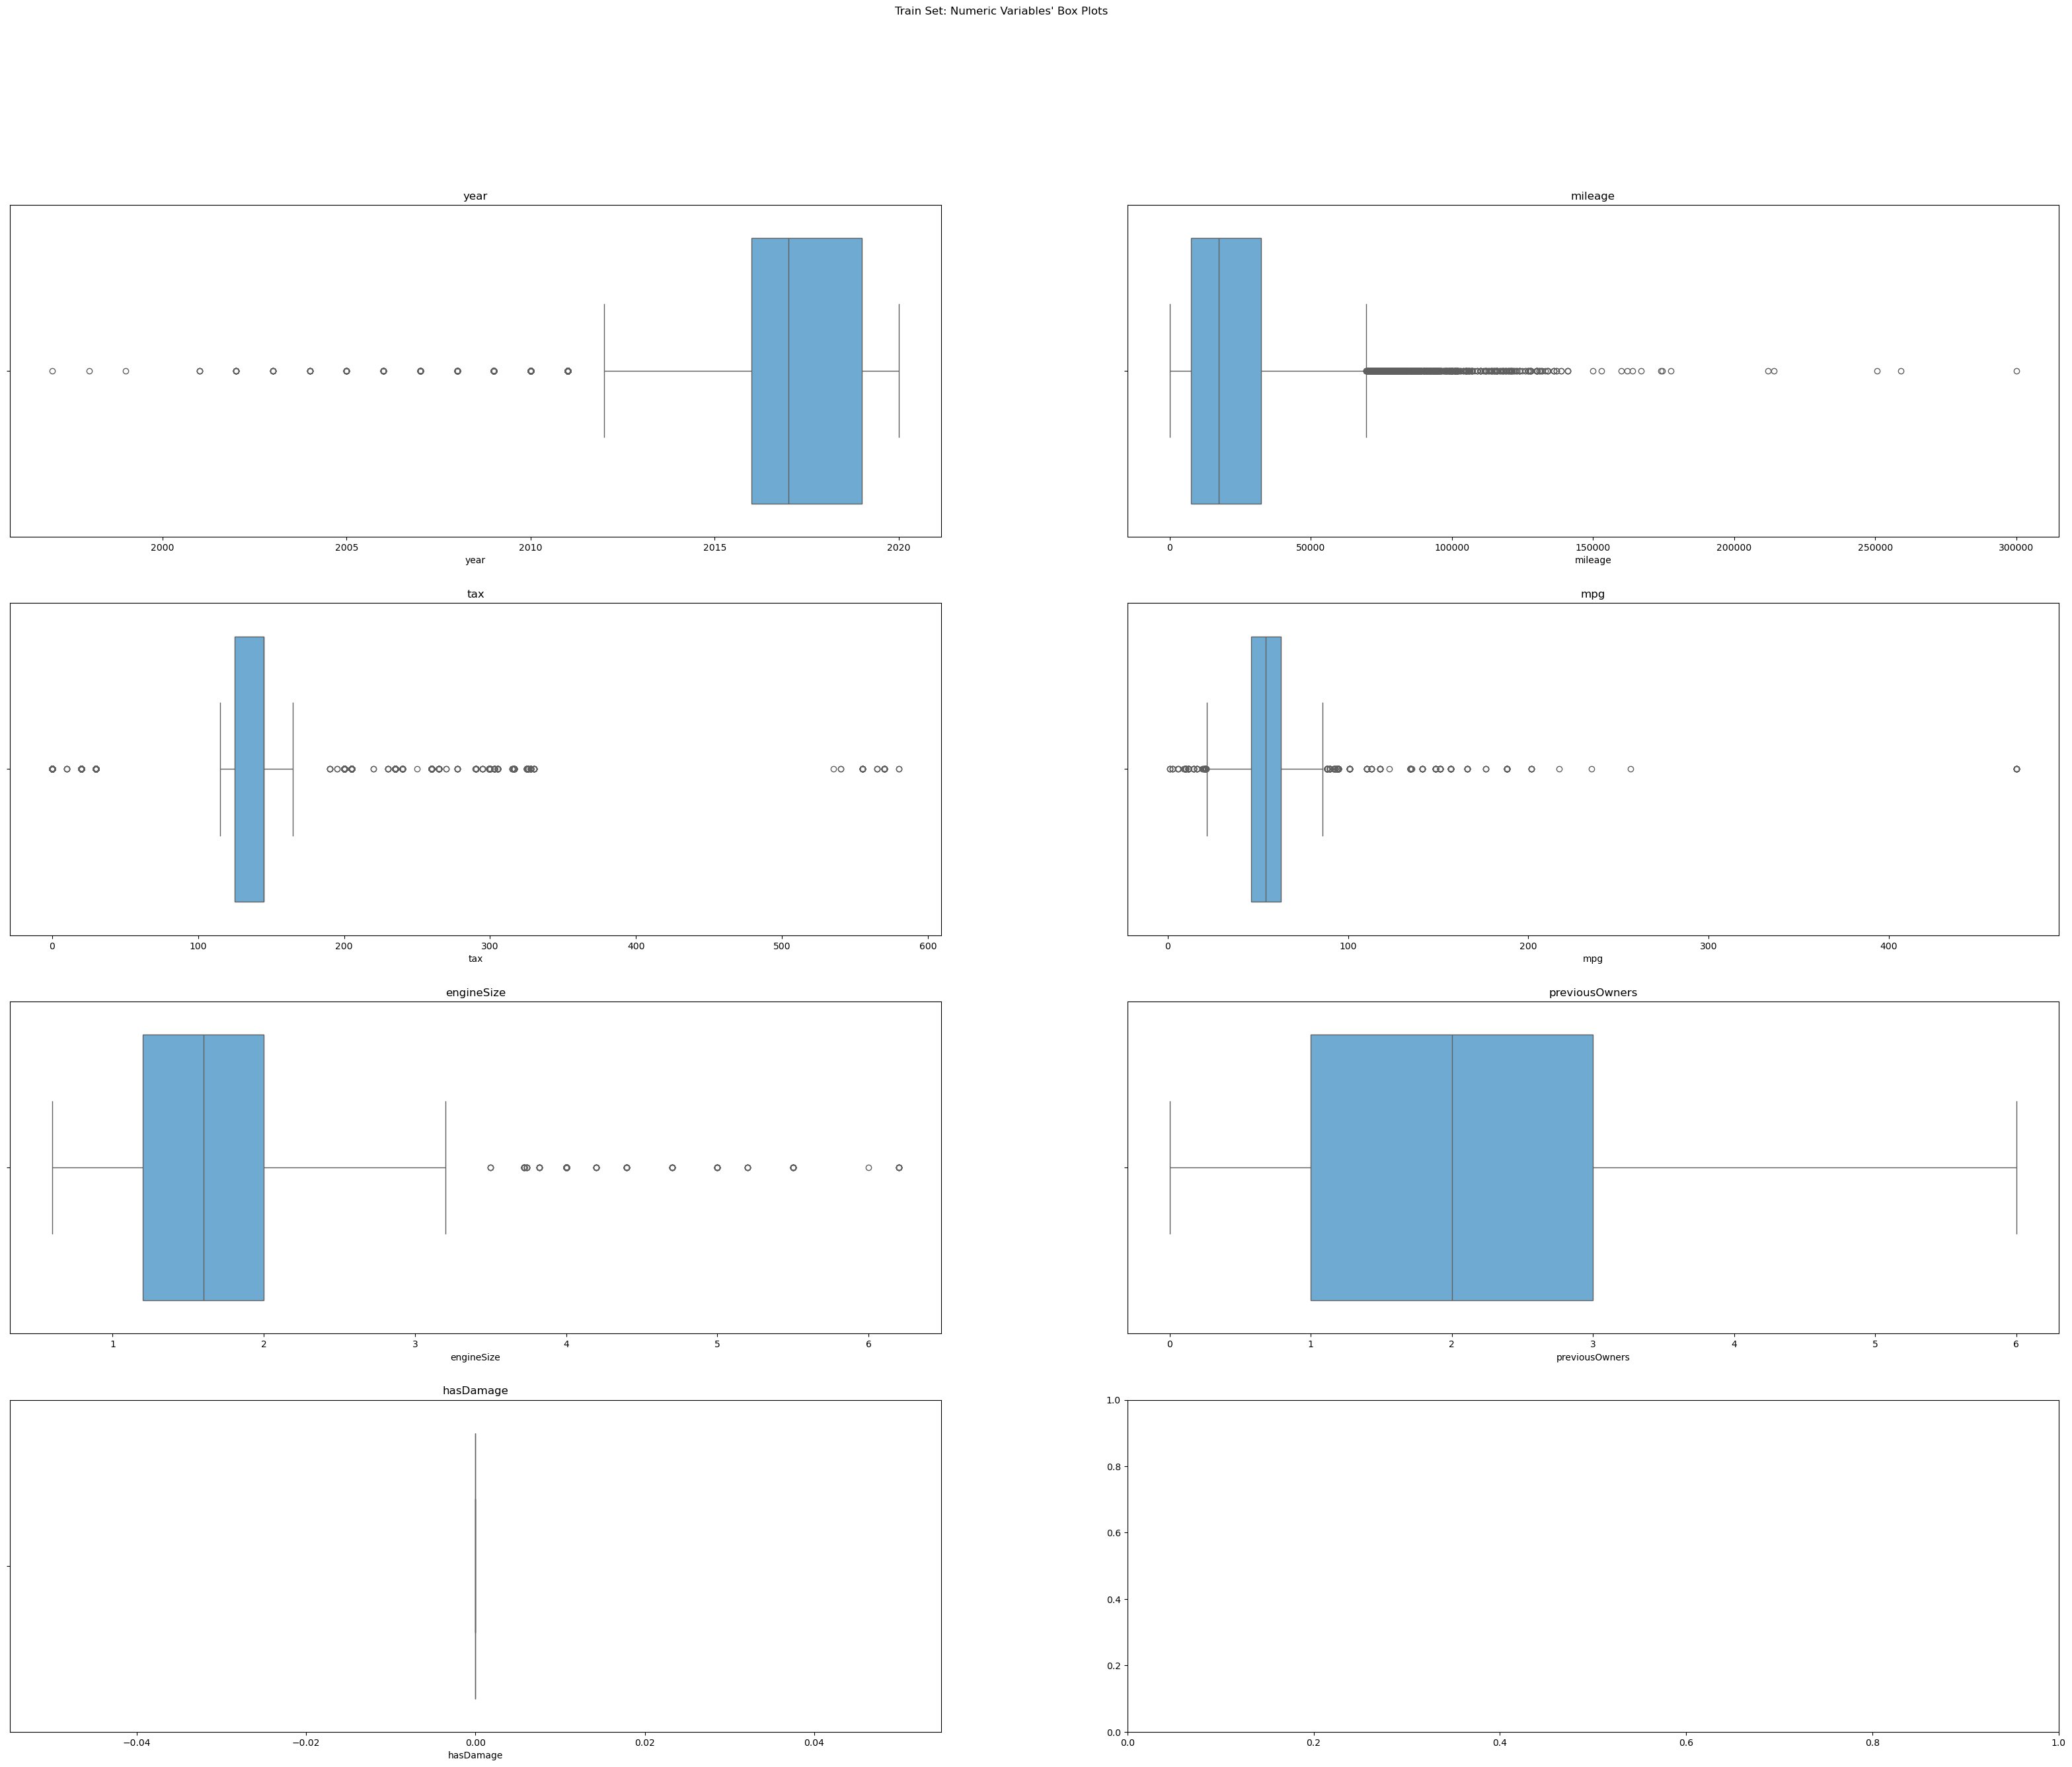

In [ ]:
#checking outliers again after handling incoherencies on X_train
plot_multiple_boxplots(X_val, metric_features, title="Train Set: Numeric Variables' Box Plots")

In [81]:
#checking outliers again after handling incoherencies on test_data
plot_multiple_boxplots(test_data, metric_features, title="Train Set: Numeric Variables' Box Plots")

NameError: name 'plot_multiple_boxplots' is not defined

**Year**

In [82]:
X_train[X_train['year'] < 1995]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
62732,Opel,Zafira,1970,Manual,37357.0,NaN,200.0,42.2,NaN,2,0
35769,Mercedes,M Class,1970,Automatic,14000.0,Diesel,305.0,39.2,NaN,3,0


In [83]:
X_val[X_val['year'] < 1995]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,


In [84]:
test_data[test_data['year'] < 1995]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
94627,Mercedes,C Class,1991,Automatic,170000.0,Petrol,NaN,NaN,3.0,4,0


In [85]:
#replacing years before 1995 by missing values for X_train and test_data
X_train.loc[X_train["year"] < 1995, "year"] = np.nan
test_data.loc[test_data["year"] < 1995, "year"] = np.nan

**Milage**

In [86]:
X_train[X_train['mileage'] > 150000]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
58385,Opel,Astra,2008,Manual,186500.0,Petrol,260.0,36.7,1.8,1,0
45553,Mercedes,C Class,2012,Automatic,170000.0,Diesel,145.0,54.3,2.1,4,0
7038,Audi,A3,2009,Manual,152034.0,Diesel,150.0,55.4,1.9,4,0
19562,Ford,Focus,2003,Manual,177644.0,Petrol,200.0,41.5,1.6,2,0
45795,Mercedes,C Class,2008,Automatic,170000.0,Diesel,NaN,NaN,2.1,3,0
67297,VW,Golf,2009,Manual,193000.0,Diesel,160.0,52.3,2.0,3,0
41580,Mercedes,C Class,2012,Automatic,170000.0,Diesel,NaN,NaN,2.1,2,0
4692,Audi,A6,2008,Manual,323000.0,Diesel,200.0,44.1,2.0,1,0
12289,BMW,3 Series,2010,Manual,156800.0,Diesel,125.0,58.9,2.0,4,0


In [87]:
X_val[X_val['mileage'] > 150000]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
48042,Skoda,Octavia,2010,Manual,250650.0,Diesel,125.0,57.6,1.9,1,0
74387,VW,Caravelle,2012,NaN,212000.0,Diesel,325.0,34.4,2.0,2,0
23427,Ford,Focus,2003,Manual,177644.0,Petrol,NaN,NaN,1.6,4,0
21764,Ford,Galaxy,2008,Manual,174000.0,Diesel,220.0,44.8,1.8,4,0
9978,BMW,X5,2012,Automatic,214000.0,Diesel,300.0,37.7,3.0,1,0
9808,BMW,3 Series,<NA>,Manual,162000.0,Diesel,205.0,49.6,2.0,0,0
45370,Mercedes,V Class,2010,Automatic,259000.0,Diesel,540.0,30.7,3.0,1,0
66971,VW,Golf,2010,Manual,164000.0,Diesel,145.0,58.9,2.0,2,0
46713,Mercedes,C Class,2007,Automatic,160000.0,Diesel,NaN,NaN,2.2,4,0


In [88]:
test_data[test_data['mileage'] > 150000]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
78147,Audi,Q5,2011,Manual,168017.0,Diesel,200.0,42.10000,2.0,0,0
91517,Mercedes,C Class,2006,Automatic,153000.0,Petrol,300.0,33.60000,1.8,3,0
102018,Opel,Astra,2001,Manual,159000.0,Petrol,235.0,40.40000,1.6,4,0
81844,BMW,5 Series,2010,Automatic,164500.0,Diesel,140.0,53.30000,2.0,3,0
94627,Mercedes,C Class,<NA>,Automatic,170000.0,Petrol,NaN,NaN,3.0,4,0
100290,Opel,Zafira,2013,Manual,279000.0,Diesel,150.0,55.40000,1.7,3,0
80858,BMW,5 Series,2013,Automatic,178987.0,Hybrid,190.0,40.40000,3.0,3,0
106256,VW,Caravelle,2006,Manual,178000.0,Diesel,325.0,34.40000,2.5,0,0
80355,BMW,3 Series,2011,Manual,190000.0,Diesel,20.0,68.90000,2.0,0,0


In [89]:
#replacing mileages higher than 150000 by missing values
X_train.loc[X_train["mileage"] > 150000, "mileage"] = np.nan
X_val.loc[X_val["mileage"] > 150000, "mileage"] = np.nan
test_data.loc[test_data["mileage"] > 150000, "mileage"] = np.nan

**Tax**

In [90]:
X_train[X_train['tax'] < 50]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
74356,VW,Golf,2016,Semi-Auto,19432.0,Diesel,30.0,62.80000,2.0,3,0
75498,VW,Polo,2016,Semi-Auto,8695.0,Petrol,20.0,60.10000,1.2,2,0
51358,Toyota,Yaris,2017,Automatic,32994.0,Petrol,30.0,55.00000,1.3,2,0
2043,Audi,A1,2016,Semi-Auto,33435.0,Petrol,30.0,70.60000,1.4,0,0
166,Audi,A5,2014,Manual,30884.0,Diesel,30.0,60.10000,2.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...
28583,Ford,B-MAX,2013,Manual,37058.0,NaN,30.0,27.70949,1.0,3,0
31202,Ford,Focus,2017,Manual,13000.0,Petrol,20.0,61.40000,1.0,4,0
2492,Audi,A4,2016,Automatic,28325.0,Diesel,0.0,72.40000,2.0,3,0


- Since the number of cars with *tax* less than 100 is large, these we will not be changed. 

In [91]:
#the same as 400
X_train[X_train['tax'] > 350]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
41531,Mercedes,SL CLASS,2016,Automatic,6200.0,Petrol,555.0,28.0,5.5,4,<NA>
44516,Mercedes,SL CLASS,2010,Automatic,79000.0,Petrol,555.0,29.1,3.5,4,0
54636,Toyota,Land Cruiser,2006,Automatic,113000.0,Diesel,555.0,31.4,3.0,0,0
37494,Mercedes,M Class,2010,Automatic,128000.0,Diesel,555.0,32.5,3.0,1,0
52900,Toyota,Land Cruiser,2014,Automatic,60000.0,Diesel,540.0,29.7,4.5,1,0
...,...,...,...,...,...,...,...,...,...,...,...
2116,Audi,RS6,2014,Automatic,59894.0,Petrol,555.0,28.8,NaN,4,0
56446,Opel,Antara,2007,Automatic,99500.0,Diesel,565.0,32.8,2.0,3,0
35606,Mercedes,M Class,2009,Automatic,59000.0,Diesel,555.0,30.4,3.0,2,0


In [92]:
X_val[X_val['tax'] > 350]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
2522,Audi,Q7,2009,Automatic,136000.0,NaN,540.0,31.0,3.0,1,0
12995,BMW,M3,2013,Automatic,58125.0,Petrol,570.0,25.2,4.0,3,0
39852,Mercedes,S Class,2010,Automatic,38000.0,Petrol,570.0,19.5,6.2,4,0
921,Audi,RS6,2014,Automatic,58000.0,Petrol,555.0,28.8,4.0,2,0
41484,Mercedes,S Class,2016,Automatic,14000.0,Petrol,555.0,28.0,5.5,4,0
73570,VW,Touareg,2007,Automatic,122965.0,Diesel,580.0,26.9,3.0,1,0
45503,Mercedes,GL Class,2007,Automatic,104000.0,Diesel,570.0,28.8,3.0,2,0
39351,NaN,GLE Class,2015,Automatic,13212.0,Petrol,570.0,23.7,NaN,2,0
34980,Mercedes,S Class,2014,Automatic,26000.0,Petrol,555.0,28.0,5.5,1,0


In [93]:
test_data[test_data['tax'] > 350]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
95966,Mercedes,S Class,2011,Automatic,66000.000000,Petrol,570.0,24.6,3.2,0,0
94732,Mercedes,S Class,2015,Automatic,23156.000000,Petrol,555.0,28.0,5.5,2,0
80066,BMW,M6,2016,Semi-Auto,26642.000000,Petrol,555.0,28.5,NaN,1,0
79095,Audi,A8,2015,Automatic,30306.000000,Petrol,570.0,25.0,6.3,2,0
80790,BMW,M5,<NA>,Automatic,55241.000000,Petrol,555.0,28.5,4.4,3,0
79753,BMW,M5,2015,Semi-Auto,42932.000000,Petrol,555.0,28.5,4.4,1,0
78115,Audi,A8,2017,Automatic,16975.000000,Petrol,555.0,28.2,4.0,0,0
103312,Opel,Insignia,2012,Manual,48490.000000,Petrol,555.0,25.9,2.8,2,0
95550,Mercedes,SL CLASS,2016,Automatic,19425.000000,NaN,555.0,NaN,5.5,0,0


In [94]:
#replacing taxes higher than 350 by missing values
X_train.loc[X_train["tax"] > 350, "tax"] = np.nan
X_val.loc[X_val["tax"] > 350, "tax"] = np.nan
test_data.loc[test_data["tax"] > 350, "tax"] = np.nan

**Mpg**

In [95]:
X_train[X_train['mpg'] > 300]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
11068,BMW,I3,2016,NaN,43695.0,Hybrid,0.0,470.8,NaN,1,0
14531,BMW,I3,2017,Automatic,36429.0,Hybrid,0.0,470.8,NaN,2,0
12332,BMW,I3,2015,Automatic,65800.0,Hybrid,0.0,470.8,NaN,3,0
9643,BMW,I3,2017,Automatic,20929.0,Hybrid,135.0,470.8,NaN,2,0
12640,BMW,I3,2017,Automatic,23956.0,NaN,135.0,470.8,0.6,1,0
12269,BMW,I3,2017,Automatic,26965.0,Hybrid,140.0,470.8,NaN,3,0
13378,BMW,I3,2015,Automatic,9886.0,Hybrid,0.0,470.8,NaN,0,0
11962,BMW,I3,2017,Automatic,21025.0,Hybrid,0.0,470.8,NaN,0,0
10327,BMW,I3,2014,Automatic,42479.0,Hybrid,0.0,470.8,NaN,2,0


In [96]:
X_val[X_val['mpg'] > 300]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
11589,BMW,I3,2016,Automatic,25269.0,NaN,0.0,470.8,0.6,0,0
8497,BMW,I3,2017,Automatic,24041.0,Hybrid,0.0,470.8,NaN,3,0
12090,BMW,I3,2016,Automatic,8421.0,Hybrid,0.0,470.8,NaN,4,0
10967,BMW,I3,2016,Automatic,41063.0,NaN,0.0,470.8,0.6,6,0
8993,BMW,I3,2016,Automatic,9990.0,NaN,0.0,470.8,NaN,0,0
10133,BMW,I3,2017,Automatic,NaN,NaN,0.0,470.8,0.6,4,0
9196,BMW,I3,2016,Automatic,19995.0,Hybrid,0.0,470.8,NaN,3,0
13075,BMW,I3,2015,Automatic,33931.0,Hybrid,0.0,470.8,NaN,4,0


In [97]:
test_data[test_data['mpg'] > 300]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
80758,BMW,I3,2016,Automatic,59945.0,Hybrid,0.0,470.8,NaN,3,0
80669,BMW,I3,2017,Automatic,28169.0,Hybrid,0.0,470.8,NaN,3,0
80184,BMW,I3,2017,Automatic,41949.0,Hybrid,140.0,470.8,NaN,4,0
81032,BMW,I3,2017,Automatic,33021.0,Hybrid,0.0,470.8,NaN,3,0
79921,BMW,I3,2017,Automatic,50867.0,NaN,135.0,470.8,0.600000,2,0
82073,BMW,I3,2015,Automatic,59000.0,NaN,0.0,470.8,0.600000,1,0
80882,BMW,I3,2017,Automatic,10900.0,Hybrid,140.0,470.8,NaN,2,0
80277,BMW,I3,2017,Automatic,26139.0,Hybrid,135.0,470.8,NaN,2,0
79191,BMW,I3,2017,Automatic,17338.0,Hybrid,135.0,470.8,NaN,0,0


- All mpg > 300 are from BMW I3 and they all have the same mpg.

In [98]:
#replacing mpg higher than 300 by missing values
X_train.loc[X_train["mpg"] > 300, "mpg"] = np.nan
X_val.loc[X_val["mpg"] > 300, "mpg"] = np.nan
test_data.loc[test_data["mpg"] > 300, "mpg"] = np.nan

**EngineSize**

In [99]:
X_train[X_train['engineSize'] > 5]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
41531,Mercedes,SL CLASS,2016,Automatic,6200.0,Petrol,NaN,28.0,5.5,4,<NA>
35538,NaN,C Class,<NA>,Semi-Auto,49964.0,Petrol,326.028233,NaN,6.2,3,0
2487,Audi,R8,2019,Semi-Auto,7800.0,Petrol,145.000000,21.4,5.2,4,0
45626,Mercedes,SL CLASS,2016,Semi-Auto,21681.0,Petrol,NaN,28.0,5.5,1,0
37895,Mercedes,GLE Class,2019,Semi-Auto,11545.0,Petrol,145.000000,23.9,5.5,2,0
35290,Mercedes,C Class,2014,Automatic,56444.0,Petrol,NaN,23.5,6.2,0,0
39752,Mercedes,C Class,2014,Automatic,56444.0,Petrol,NaN,NaN,6.2,3,0
2022,Audi,R8,2019,Automatic,8175.0,Petrol,145.000000,21.6,5.2,4,0
40976,Mercedes,GLE Class,2019,Semi-Auto,9.0,Petrol,145.000000,23.7,5.5,1,0


In [100]:
X_val[X_val['engineSize'] > 5]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
6647,Audi,R8,<NA>,Semi-Auto,4000.000000,Petrol,145.0,21.4,5.2,4,0
44293,Mercedes,S Class,1998,Automatic,43534.000000,Petrol,NaN,23.3,6.0,2,0
44376,Mercedes,SL CLASS,2019,Semi-Auto,3728.000000,Petrol,145.0,28.0,5.5,1,0
39852,Mercedes,S Class,2010,Automatic,38000.000000,Petrol,NaN,19.5,6.2,4,0
46372,Mercedes,C Class,2013,Semi-Auto,49964.000000,Petrol,NaN,23.0,6.2,3,0
41484,Mercedes,S Class,2016,Automatic,14000.000000,Petrol,NaN,28.0,5.5,4,0
46668,Mercedes,GLE Class,2017,Automatic,7000.000000,Petrol,145.0,29.5,5.5,3,0
34980,Mercedes,S Class,2014,Automatic,26000.000000,Petrol,NaN,28.0,5.5,1,0
36076,Mercedes,SL CLASS,2017,Semi-Auto,NaN,Petrol,145.0,28.0,5.5,0,0


In [101]:
test_data[test_data['engineSize'] > 5]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,
94732,Mercedes,S Class,2015,Automatic,23156.000000,Petrol,NaN,28.0,5.5,2,0
79095,Audi,A8,2015,Automatic,30306.000000,Petrol,NaN,25.0,6.3,2,0
95550,Mercedes,SL CLASS,2016,Automatic,19425.000000,NaN,NaN,NaN,5.5,0,0
92738,Mercedes,CLS Class,2012,Automatic,46283.000000,Petrol,NaN,28.5,5.5,3,0
91008,Mercedes,GL Class,2014,Automatic,55000.000000,Petrol,NaN,23.0,5.5,4,<NA>
76804,Audi,R8,2020,Semi-Auto,333.000000,Petrol,145.0,21.4,5.2,1,0
94754,Mercedes,C Class,2013,Automatic,41866.000000,Petrol,NaN,NaN,6.2,1,0
77563,Audi,R8,2019,Automatic,11936.000000,Petrol,145.0,21.4,5.2,0,0
95730,Mercedes,SL CLASS,2014,Semi-Auto,86705.854885,Petrol,NaN,28.5,5.5,3,0


In [102]:
#replacing mileages higher than 150000 by missing values
X_train.loc[X_train["engineSize"] > 5, "engineSize"] = np.nan
X_val.loc[X_val["engineSize"] > 5, "engineSize"] = np.nan
test_data.loc[test_data["engineSize"] > 5, "engineSize"] = np.nan

### 4.7. Treating Missing Values

#### 4.7.1. Encoding Categorical Features

- Here, we want to fill the missing values of each car taking into account its *brand* and *model*. Therefore, we are going to encode these variables to transform them into numerical.
- Moreover, we transform the rest of the categoreical variables (transmission and fuelType) into numerical through get dummies, in order to fill them as well along with the other and using KNN inputer. 

In [103]:
X_train.isna().sum().sort_values(ascending=False)

tax               5733
mpg               5434
transmission      1637
engineSize        1495
year              1302
mileage           1248
model             1175
fuelType          1142
hasDamage         1094
previousOwners    1091
Brand             1053
dtype: int64

In [104]:
X_val.isna().sum().sort_values(ascending=False)

tax               2539
mpg               2424
transmission       626
engineSize         607
mileage            565
year               548
fuelType           536
model              529
Brand              468
previousOwners     459
hasDamage          454
dtype: int64

In [105]:
test_data.isna().sum().sort_values(ascending=False)

tax               3524
mpg               3321
transmission       971
engineSize         878
mileage            873
year               834
fuelType           738
model              713
Brand              649
previousOwners     597
hasDamage          597
dtype: int64

In [106]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.neural_network import MLPRegressor

#### 4.7.2. Interactive Imputer

In [107]:
freq_encoding_brand = X_train['Brand'].value_counts()
X_train['brand_encoded'] = X_train['Brand'].map(freq_encoding_brand)
X_val['brand_encoded'] = X_val['Brand'].map(freq_encoding_brand)
test_data['brand_encoded'] = test_data['Brand'].map(freq_encoding_brand)

In [108]:
freq_encoding_model = X_train['model'].value_counts()
X_train['model_encoded'] = X_train['model'].map(freq_encoding_model)
X_val['model_encoded'] = X_val['model'].map(freq_encoding_model)
test_data['model_encoded'] = test_data['model'].map(freq_encoding_model)

In [109]:
freq_encoding_transmission = X_train['transmission'].value_counts()
X_train['transmission_encoded'] = X_train['transmission'].map(freq_encoding_transmission)
X_val['transmission_encoded'] = X_val['transmission'].map(freq_encoding_transmission)
test_data['transmission_encoded'] = test_data['transmission'].map(freq_encoding_transmission)

In [110]:
rare_fuels = ['Electric', 'Other']
X_train['fuelType'] = X_train['fuelType'].replace(rare_fuels, 'Other')
X_val['fuelType'] = X_val['fuelType'].replace(rare_fuels, 'Other')
test_data['fuelType'] = test_data['fuelType'].replace(rare_fuels, 'Other')

freq_encoding_fuel = X_train['fuelType'].value_counts() 
X_train['fuelType_encoded'] = X_train['fuelType'].map(freq_encoding_fuel)
X_val['fuelType_encoded'] = X_val['fuelType'].map(freq_encoding_fuel)
test_data['fuelType_encoded'] = test_data['fuelType'].map(freq_encoding_fuel)

In [111]:
X_val.isna().sum().sort_values(ascending=False)

tax                     2539
mpg                     2424
transmission             626
transmission_encoded     626
engineSize               607
mileage                  565
year                     548
fuelType                 536
fuelType_encoded         536
model_encoded            533
model                    529
Brand                    468
brand_encoded            468
previousOwners           459
hasDamage                454
dtype: int64

In [112]:
test_data.isna().sum().sort_values(ascending=False)

tax                     3524
mpg                     3321
transmission             971
transmission_encoded     971
engineSize               878
mileage                  873
year                     834
fuelType                 738
fuelType_encoded         738
model_encoded            729
model                    713
Brand                    649
brand_encoded            649
hasDamage                597
previousOwners           597
dtype: int64

In [113]:
X_train = X_train.drop(['Brand', 'model', 'transmission', 'fuelType'], axis=1)
X_val = X_val.drop(['Brand', 'model', 'transmission', 'fuelType'], axis=1)
test_data = test_data.drop(['Brand', 'model', 'transmission', 'fuelType'], axis=1)

In [114]:
# ensuring that y_train has the same rows X_train
y_train = y_train.loc[X_train.index]
y_val = y_val.loc[X_val.index]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (52817, 11)
y_train shape: (52817,)


In [115]:
X_val.isna().sum().sort_values(ascending=False)

tax                     2539
mpg                     2424
transmission_encoded     626
engineSize               607
mileage                  565
year                     548
fuelType_encoded         536
model_encoded            533
brand_encoded            468
previousOwners           459
hasDamage                454
dtype: int64

In [116]:
#checking if X_train and y_train have the same number of rows
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (52817, 11)
y_train shape: (52817,)


In [117]:
#Define the columns
num_cols = ['mileage', 'mpg', 'tax', 'engineSize', 'previousOwners', 'year', 'fuelType_encoded', 'model_encoded', 'brand_encoded', 'transmission_encoded', 'hasDamage']


In [118]:
# Make copies so we don’t overwrite original data
X_train_imp = X_train.copy()
X_val_imp   = X_val.copy()
test_imp    = test_data.copy()

# ---------------------------------------------
# 2. Define the ExtraTrees regressor for imputation
# ---------------------------------------------
num_imputer_ETR = ExtraTreesRegressor(
    n_estimators=80,
    max_depth=12,
    min_samples_leaf=2,
    max_features=None,
    n_jobs=-1,
    random_state=42
)

# ---------------------------------------------
# 3. Define the Iterative Imputer
# ---------------------------------------------
num_imputer = IterativeImputer(
    estimator=num_imputer_ETR,
    max_iter=12,
    initial_strategy='median',
    imputation_order='ascending',
    skip_complete=True,
    random_state=42
)

# ---------------------------------------------
# 4. Fit on TRAIN and transform VAL + TEST
# ---------------------------------------------
train_imputed = num_imputer.fit_transform(X_train_imp[num_cols])
val_imputed   = num_imputer.transform(X_val_imp[num_cols])
test_imputed  = num_imputer.transform(test_imp[num_cols])

# ---------------------------------------------
# 5. Put imputed values back into the DataFrames
# ---------------------------------------------
X_train_imp[num_cols] = train_imputed
X_val_imp[num_cols]   = val_imputed
test_imp[num_cols]    = test_imputed

# ---------------------------------------------
# 6. Check missing values
# ---------------------------------------------
print("Missing after imputation (TRAIN):\n", X_train_imp[num_cols].isna().sum())
print("\nMissing after imputation (VAL):\n", X_val_imp[num_cols].isna().sum())
print("\nMissing after imputation (TEST):\n", test_imp[num_cols].isna().sum())

c:\Users\Catarina\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Missing after imputation (TRAIN):
 mileage                 0
mpg                     0
tax                     0
engineSize              0
previousOwners          0
year                    0
fuelType_encoded        0
model_encoded           0
brand_encoded           0
transmission_encoded    0
hasDamage               0
dtype: int64

Missing after imputation (VAL):
 mileage                 0
mpg                     0
tax                     0
engineSize              0
previousOwners          0
year                    0
fuelType_encoded        0
model_encoded           0
brand_encoded           0
transmission_encoded    0
hasDamage               0
dtype: int64

Missing after imputation (TEST):
 mileage                 0
mpg                     0
tax                     0
engineSize              0
previousOwners          0
year                    0
fuelType_encoded        0
model_encoded           0
brand_encoded           0
transmission_encoded    0
hasDamage               0
dtype: int64

In [119]:
X_train = X_train_imp
X_val = X_val_imp
test_data = test_imp

- Since we fit the train dataset and transform the validation and test dataset, there is the possibility of the validation and test dataset still have missing values after the interactive imputer because there are categories in *model* that never appeared in the training set so the imputer cannot impute them and leaves them as missing.
- Therefore, we have decided to fill these missing values with the mode. We have considered this option because the quantity of missing values left to fill is reduced (4 for validation and 16 for test).

**Links:**
- https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html
- https://chatgpt.com/share/692cad70-3fdc-8007-a212-ca8d1e5c714a

### 4.8. Feature Engineering

#### 4.8.1. Creating New Variables

In [120]:
X_train['engineEfficiency'] = X_train['mpg'] / X_train['engineSize']
X_val['engineEfficiency'] = X_val['mpg'] / X_val['engineSize']
test_data['engineEfficiency'] = test_data['mpg'] / test_data['engineSize']

### 4.9. Scaling

In [121]:
#scale the variables using MinMaxScaler()
var = ['tax', 'mpg', 'mileage', 'engineSize', 'hasDamage', 'previousOwners', 'year', 'engineEfficiency', 'brand_encoded',  'model_encoded', 'fuelType_encoded', 'transmission_encoded']
scaler = MinMaxScaler()

# fitting the scaler only on training dataset (to avoid leakage)
X_train[var] = scaler.fit_transform(X_train[var])

# transforming validation and test dataset using the same scaling
X_val[var] = scaler.transform(X_val[var])
test_data[var] = scaler.transform(test_data[var])

In [122]:
#checking if X_train and y_train have the same number of rows
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (52817, 12)
y_train shape: (52817,)


In [123]:
#checking if X_val and y_val have the same number of rows
print("X_val shape:", X_train.shape)
print("y_val shape:", y_train.shape)

X_val shape: (52817, 12)
y_val shape: (52817,)


In [124]:
X_val.head()

,year,mileage,tax,mpg,engineSize,previousOwners,hasDamage,brand_encoded,model_encoded,transmission_encoded,fuelType_encoded,engineEfficiency
carID,,,,,,,,,,,,
37025,0.833333,0.215711,0.090909,0.250000,0.227273,0.000000,0.0,0.654410,0.774323,0.069878,0.753043,0.250000
65090,0.791667,0.406663,0.484848,0.180719,0.181818,0.166667,0.0,0.469416,0.086929,1.000000,1.000000,0.206536
29197,0.916667,0.058920,0.439394,0.224688,0.090909,0.000000,0.0,1.000000,1.000000,1.000000,1.000000,0.359502
22100,0.958333,0.041460,0.439394,0.229361,0.090909,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,0.366978
70417,0.958333,0.041387,0.439394,0.186526,0.090909,0.500000,0.0,0.558305,0.031937,1.000000,1.000000,0.298442


In [125]:
test_data.head()

,year,mileage,tax,mpg,engineSize,previousOwners,hasDamage,brand_encoded,model_encoded,transmission_encoded,fuelType_encoded,engineEfficiency
carID,,,,,,,,,,,,
89856,0.815600,0.204661,0.621212,0.161604,0.227273,0.500000,0.0,0.000000,0.052453,0.000000,1.000000,0.161604
106581,0.875000,0.146227,0.454545,0.148754,0.318182,0.333333,0.0,0.558305,0.184645,0.069878,1.000000,0.119003
80886,0.833333,0.245275,0.378788,0.200156,0.204545,0.333333,0.0,0.315464,0.119078,0.000000,1.000000,0.213499
100174,0.958333,0.036880,0.439394,0.171729,0.136364,0.166667,0.0,0.469416,0.057953,1.000000,1.000000,0.228972
81376,0.958333,0.060380,0.454545,0.200156,0.318182,0.666667,0.0,0.315464,0.201142,0.069878,0.753043,0.160125


In [126]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32567 entries, 89856 to 99627
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  32567 non-null  float64
 1   mileage               32567 non-null  float64
 2   tax                   32567 non-null  float64
 3   mpg                   32567 non-null  float64
 4   engineSize            32567 non-null  float64
 5   previousOwners        32567 non-null  float64
 6   hasDamage             32567 non-null  float64
 7   brand_encoded         32567 non-null  float64
 8   model_encoded         32567 non-null  float64
 9   transmission_encoded  32567 non-null  float64
 10  fuelType_encoded      32567 non-null  float64
 11  engineEfficiency      32567 non-null  float64
dtypes: float64(12)
memory usage: 3.2 MB


### 4.10. Feature Selection
In order to correctly predict the price of the cars in our test dataset, it is important to chose a group of features that would be sufficient relevant to train the model. The choice of what features to keep was taken based on the analysis of filter, wrapper and embedded methods. The filter methods developed were the *Variance*, the *Spearman Correlation Matrix* and the *Mutual Information (MI)*, while in terms of wrapper methods, the *RFECV* and the *Sequential Feature Selector* with *Forward Selection* were the two methods chosen. In addition, *Lasso* and *Random Forest Feature Importance* were also taken into consideration as part of embedded methods. 
We have decided to analyse and retrieving insights of each method individually and, at the end, grouping all information in one table, it is could be easier to understan what features should be kept. 
In feature selection, we are only going to consider

#### 4.10.1. Filter Methods 
This methods are caracterized by being statistical approaches that do not consider any machine learning algorithm. Our objective is to compare our features against the target variable (*price*). However, these methods solely are not enough to conduct a good feature selection due to the fact that we are only looking to correlations between two variables at a time. There are cases where a variable can be "jointly significant". 

##### 4.10.1.1. Variance
First, we looked at the variance of each variable to understand if there are variables whose variance is null or almost null. If a variable is null, it means it is irrelavant for training the model because all their observations are equal or similiar, not adding any new information. 

In [127]:
X_train.var()

year                    0.008047
mileage                 0.020207
tax                     0.034422
mpg                     0.003055
engineSize              0.015404
previousOwners          0.056252
hasDamage               0.000000
brand_encoded           0.095151
model_encoded           0.094314
transmission_encoded    0.224916
fuelType_encoded        0.035169
engineEfficiency        0.008968
dtype: float64

In [128]:
X_val.var()

year                    0.007845
mileage                 0.019677
tax                     0.034154
mpg                     0.003062
engineSize              0.015582
previousOwners          0.056101
hasDamage               0.000000
brand_encoded           0.095177
model_encoded           0.095625
transmission_encoded    0.226460
fuelType_encoded        0.035573
engineEfficiency        0.009054
dtype: float64

As previously seen, *hasDamaged* has a variance of 0, which is an indicator that would not be kept in the model. None of the remain variables presents a variance near 0, so according to this method, all variables should be kept except for **hasDamaged**.

##### 4.10.1.2. Spearman correlation

In [129]:
# Combine X_train and y_train into one dataframe
df_train = X_train.copy()
df_train['price'] = y_train.values  # ensure alignment

# Compute Spearman correlation
cor_spearman = df_train.corr(method='spearman')
cor_spearman

,year,mileage,tax,mpg,engineSize,previousOwners,hasDamage,brand_encoded,model_encoded,transmission_encoded,fuelType_encoded,engineEfficiency,price
year,1.000000,-0.800864,0.344966,-0.303706,-0.033472,-0.000040,NaN,-0.012309,-0.025419,-0.134703,0.102674,-0.132860,0.599896
mileage,-0.800864,1.000000,-0.291592,0.323993,0.098063,0.005947,NaN,0.012800,0.028696,0.114400,-0.195347,0.096828,-0.520968
tax,0.344966,-0.291592,1.000000,-0.561051,0.154224,0.002281,NaN,0.011952,-0.098814,-0.154899,0.186715,-0.420722,0.333647
mpg,-0.303706,0.323993,-0.561051,1.000000,-0.192635,0.003273,NaN,0.074312,0.234376,0.183315,-0.394411,0.685839,-0.374521
engineSize,-0.033472,0.098063,0.154224,-0.192635,1.000000,0.000225,NaN,-0.088633,-0.235121,-0.505705,-0.615470,-0.819576,0.575504
previousOwners,-0.000040,0.005947,0.002281,0.003273,0.000225,1.000000,NaN,0.006140,0.000631,0.007324,0.001470,0.000079,-0.003689
hasDamage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand_encoded,-0.012309,0.012800,0.011952,0.074312,-0.088633,0.006140,NaN,1.000000,0.519602,0.108794,0.045261,0.112048,-0.012516
model_encoded,-0.025419,0.028696,-0.098814,0.234376,-0.235121,0.000631,NaN,0.519602,1.000000,0.165649,0.171696,0.288077,-0.168463
transmission_encoded,-0.134703,0.114400,-0.154899,0.183315,-0.505705,0.007324,NaN,0.108794,0.165649,1.000000,0.317687,0.449979,-0.544549


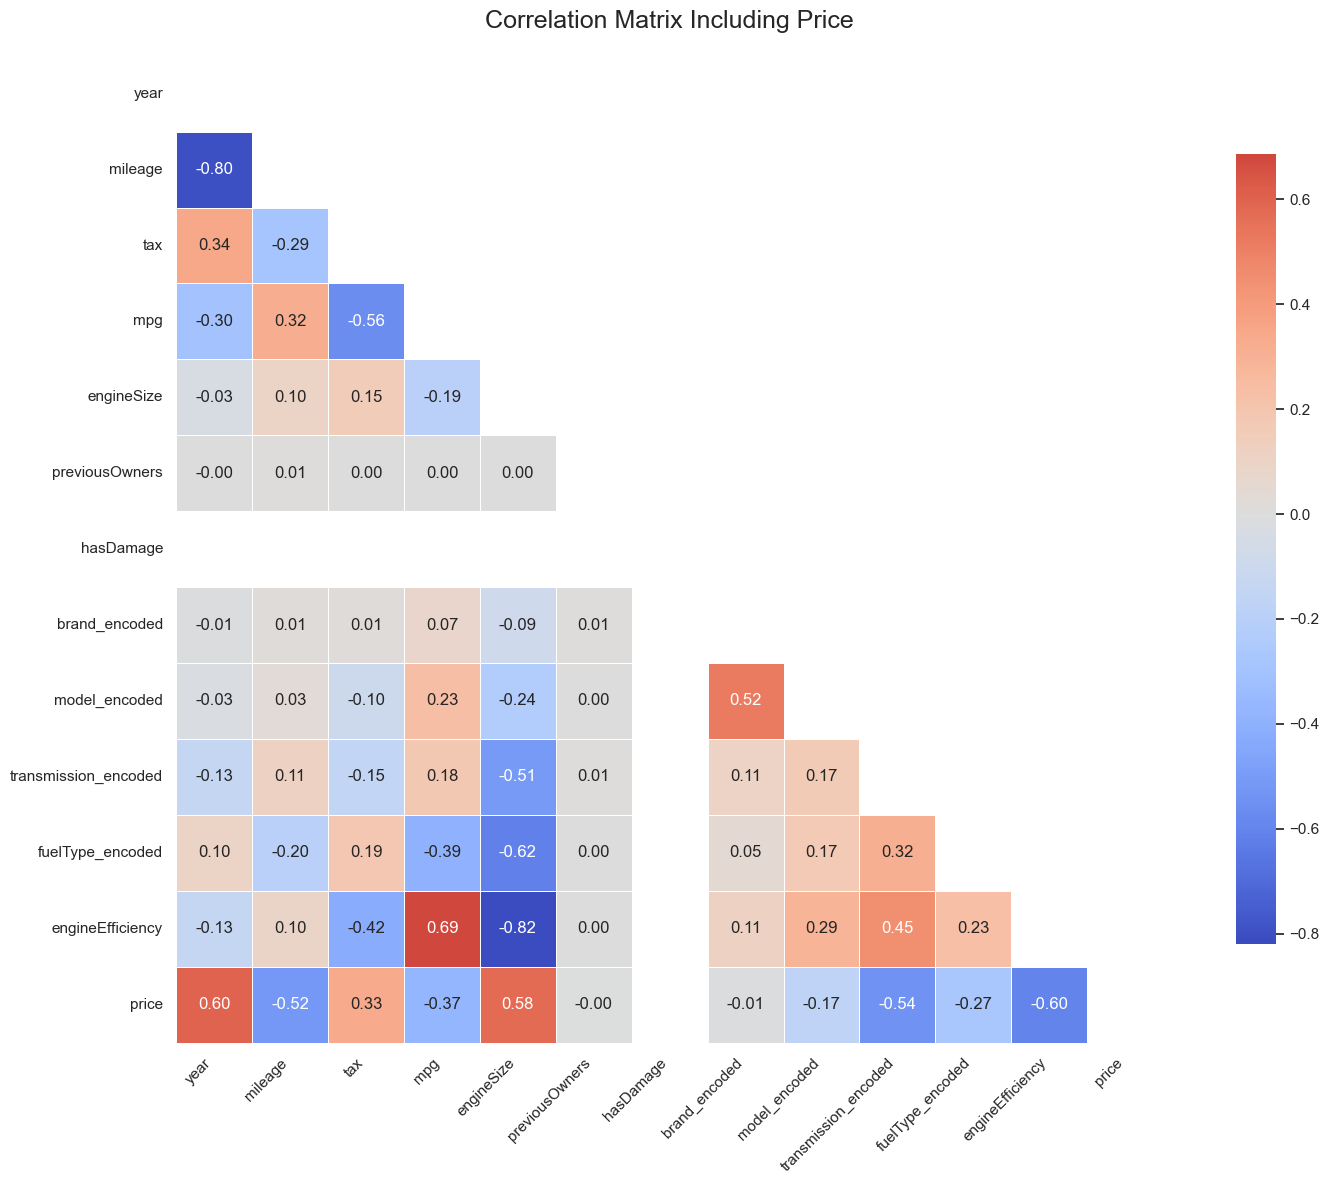

In [130]:
# Create mask for upper triangle
mask = np.triu(np.ones_like(cor_spearman, dtype=bool))

# White style
sns.set_theme(style="white")

# Plot
plt.figure(figsize=(16, 12))

sns.heatmap(
    cor_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Matrix Including Price", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

As already seen in data exploration, the only two couple of features that have a high correlation (<|0.8|) are *mileage* vs *year* and *engineEfficiency* vs *engineSize*, which present a negative correlation of -0.80 and -0.82, respectively. It is important to note that, even though, 
these correlations are usually a signal of redundance, all of them have good correlations with *price* (either positives or negatives correlations), and correlation matrixes only give information about linear relationships, which, as seen before, do not have a high predominance in our dataset. For that reason, according to this analysis, this variables should be kept in our model.  
In addition, *previousOwners*, *hasDamaged* and *fuelType_Other* has no correlation or very few correlation with other variables, including *price*. 
This indicates these features are not relevant to predict our target.
Therefore, according to this method, all variables should be kept except for **hasDamaged** and **previousOwners**.

##### 4.10.1.3. Mutual Information (MI)

In [139]:
print(X_train.shape, y_train.shape)

(52817, 12) (52817,)


In [140]:
mi_scores = mutual_info_regression(X_train, y_train, random_state=0)

mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print(mi_df.head(10))

top_mi_features = mi_df.head(15)['Feature']
X_train_mi = X_train[top_mi_features]

                 Feature  MI_Score
11      engineEfficiency  0.713880
8          model_encoded  0.602470
3                    mpg  0.401742
4             engineSize  0.391511
0                   year  0.339337
7          brand_encoded  0.319833
1                mileage  0.295212
9   transmission_encoded  0.262135
2                    tax  0.232215
10      fuelType_encoded  0.071321


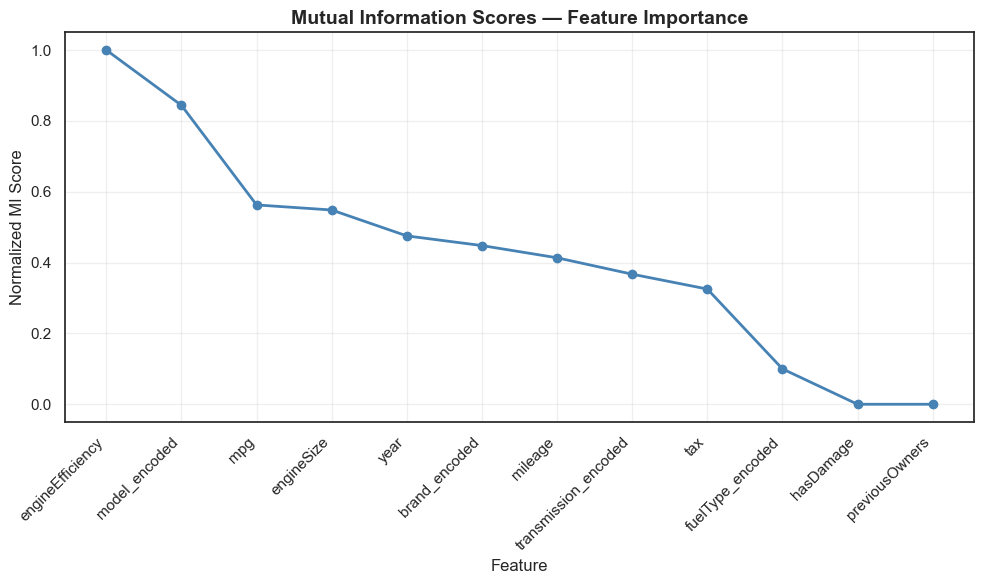

In [141]:
mi_df = mi_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)
mi_df['MI_Score_norm'] = mi_df['MI_Score'] / mi_df['MI_Score'].max()

# Plot clean MI curve
plt.figure(figsize=(10, 6))
plt.plot(mi_df['Feature'], mi_df['MI_Score_norm'], marker='o', color='steelblue', linewidth=2)
plt.title("Mutual Information Scores — Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Normalized MI Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Considering that *Spearman Correlation Matrix* only analysis linear relationships, we have decided to perform the *Mutual Information (MI)* that gives us information about nonlinear predictive power of features. 
The MI scores show that *engineEfficiency* and *model_encode*d are the two most informative predictors, followed by *mpg*, *engineSize*, *year*, *brand_encoded* and *mileage*.
After the top 7 features, the MI values either flatten considerably or the Normalized MI score is low (<0.4), indicating that additional variables give us little new information to predict *price*. 
Therefore, according to this method, the variables **previousOwners**, **hasDamaged**, **fuelType_encoded**, **transmission_encoded** and **tax** should not be consider when training the model

#### 4.10.2. Wrapper Methods 
In addition to the filter methods, we also analysed wrapper methods that evaluate features based on actual model performances. In this way, we were able to detect interactions between features, since some of them may be considered weak alone but strong when combined, or redundant when another feature is present in the model. Here, we evaluated the sets of features based on *Root Mean Square Error (RMSQ)* that inform us how far off the model's predicted car prices are from the real prices, on average. That is the lower the value, the better the model is making predictions. 

##### 4.10.2.1. RFECV

In [146]:
# Combine train and validation datasets
X_combined = np.concatenate([X_train, X_val])
y_combined = np.concatenate([y_train, y_val])

# Create a test fold index (-1 for train, 0 for validation)
test_fold = [-1] * len(X_train) + [0] * len(X_val)

print('Test fold: ', len(test_fold))
print('X_combined: ', len(X_combined))
print('y_combined: ', len(y_combined))

# Define the PredefinedSplit
ps = PredefinedSplit(test_fold=test_fold)

Test fold:  75522
X_combined:  75522
y_combined:  75522


In [147]:
# preprune random forest

base_estimator = RandomForestRegressor(
    n_estimators=200,   # number of trees
    max_depth=10,
    min_samples_leaf = 4,
    max_features="sqrt",
    random_state=0,
    n_jobs=-1
)

In [148]:
# Find number of features
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 3. Execute RFECV to find the optimal feature count based on Validation RMSE
# Using the balanced estimator for the primary optimization process.
rfecv_selector = RFECV(
    estimator=base_estimator, 
    step=1,
    cv=ps, # Uses the PredefinedSplit (X_val) for scoring
    scoring=neg_mse_scorer
)
rfecv_selector.fit(X_combined, y_combined)

# --- Define the range of features evaluated by RFECV (for the X-axis) ---
feature_counts_range = rfecv_selector.cv_results_['n_features']

# 4. Calculate Training RMSE for the plot (MANUAL LOOP CORRECTED)
# We calculate the Training score for each feature subset size determined by the ranking.
train_rmse_list = []
feature_ranking = rfecv_selector.ranking_

for n in feature_counts_range:
    # Identify the features selected at this step (rank <= n)
    selected_features_mask = feature_ranking <= n
    
    # Subset X_train using the mask, assuming X_train is a Pandas DataFrame.
    X_train_subset = X_train.iloc[:, selected_features_mask]
    
    # Train on the SUBSET of features
    base_estimator.fit(X_train_subset, y_train)
    
    # Predict and calculate Training RMSE on the SUBSET of features
    train_pred = base_estimator.predict(X_train_subset)
    train_mse = mean_squared_error(y_train, train_pred)
    train_rmse_list.append(np.sqrt(train_mse))


# 5. Prepare Plotting Data and Output
optimal_nof = rfecv_selector.n_features_
validation_scores_neg_mse = rfecv_selector.cv_results_['mean_test_score']
# Convert Validation Negative MSE scores to positive RMSE
validation_rmse = np.sqrt(-validation_scores_neg_mse) 
# The index of the optimal number of features is optimal_nof - 1
min_rmse = validation_rmse[optimal_nof - 1] 

# Variables for Plotting
nof_list = feature_counts_range
val_rmse_list = validation_rmse
nof = optimal_nof
low_rmse = min_rmse

print("\n--- RFECV Results (Using Random Forest) ---")
print(f"Optimal number of features found: {nof}")
print(f"Minimum Validation RMSE achieved: {low_rmse:.4f}")


--- RFECV Results (Using Random Forest) ---
Optimal number of features found: 9
Minimum Validation RMSE achieved: 2938.5113


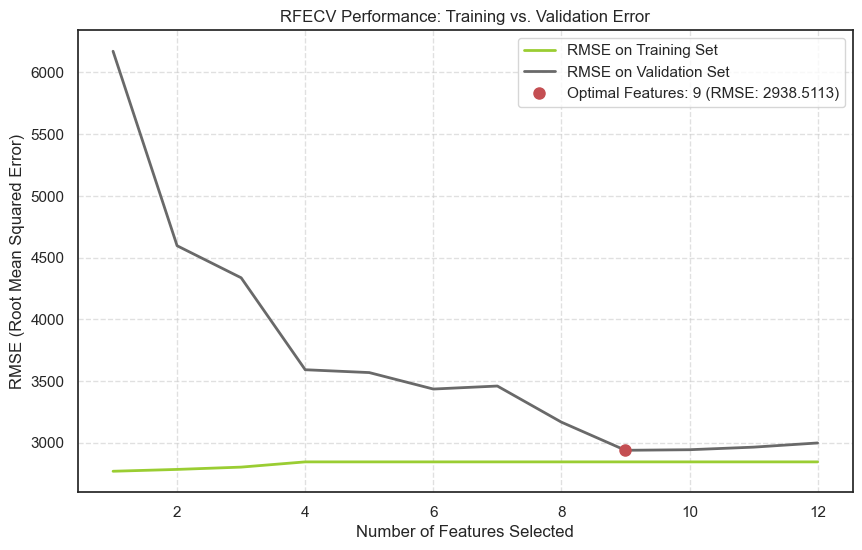

In [149]:
# Plot figure

plt.figure(figsize=(10, 6))

# Training RMSE (NEWLY ADDED)
plt.plot(nof_list, train_rmse_list,
         label="RMSE on Training Set", color='yellowgreen', linewidth=2) 
         
# Validation RMSE
plt.plot(nof_list, val_rmse_list, 
         label="RMSE on Validation Set", color='dimgray', linewidth=2) 

# Highlight the optimal point
plt.plot(nof, low_rmse, 'ro', 
         label=f'Optimal Features: {nof} (RMSE: {low_rmse:.4f})', markersize=8)

plt.xlabel("Number of Features Selected")
plt.ylabel("RMSE (Root Mean Squared Error)") 
plt.title("RFECV Performance: Training vs. Validation Error")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [150]:
# Get the mask of selected features (True for selected, False otherwise)
# rfecv_selector.support_ stores the mask corresponding to the optimal_nof
selected_feature_mask = rfecv_selector.support_

forward_features = X_train.columns[selected_feature_mask]

print("Selected features using RFECV ({} features):".format(optimal_nof))
print(list(forward_features))

Selected features using RFECV (9 features):
['year', 'mileage', 'tax', 'mpg', 'engineSize', 'brand_encoded', 'model_encoded', 'transmission_encoded', 'engineEfficiency']


According to *RFECV* with *Random Forest* as estimator, the optimal number of features to keep would be 9 as this combination of features reveal the lowest validation RMSE. The minimum score was 2938.5113, indicating that the model’s average prediction error is about £2938.
Therefore, according to this method, the variables to be discarded are **previousOwners**, **fuelType_encoded** and **hasDamaged**

##### 4.10.2.2. Sequential Forward Feature Selector

In [151]:
from sklearn.feature_selection import SequentialFeatureSelector

#forward selection

sfs_forward = SequentialFeatureSelector(
    estimator=base_estimator,
    n_features_to_select="auto",   # Let SFS find optimal count
    direction="forward",
    scoring="neg_mean_squared_error",
    cv=ps,                          # small CV to reduce compute
    n_jobs=-1,
    tol=1e-3  
)

sfs_forward.fit(X_combined, y_combined)

# Selected feature mask and names
forward_mask = sfs_forward.get_support()
forward_features = X_train.columns[forward_mask]

print("Forward Selected Features:")
print(list(forward_features))

# Evaluate on validation set
base_estimator.fit(X_train[forward_features], y_train)
y_val_pred_forward = base_estimator.predict(X_val[forward_features])
val_rmse_forward = np.sqrt(mean_squared_error(y_val, y_val_pred_forward))

# Calculate Training RMSE 
y_train_pred_forward = base_estimator.predict(X_train[forward_features])
train_rmse_forward = np.sqrt(mean_squared_error(y_train, y_train_pred_forward))

print("Training RMSE (Forward SFS):", train_rmse_forward)
print("Validation RMSE (Forward SFS):", val_rmse_forward)

Forward Selected Features:
['year', 'mileage', 'mpg', 'engineSize', 'brand_encoded', 'model_encoded', 'transmission_encoded', 'fuelType_encoded', 'engineEfficiency']
Training RMSE (Forward SFS): 2731.140286662351
Validation RMSE (Forward SFS): 2893.718946611841


In constract with *RFECV*, *Sequential Forward Feature Selection* stated that the optimal number of features would only be 9. 
Therefore, according to this method, the features that should be removed are **previousOwners**, **fuelType_encoded** and **hasDamaged**.

#### 4.10.3. Embedded Methods 
As a way of complementing filter and wrapper methods, we have decided to also analyse some embedded methods since learn which features best contribute to the accuracy of the model while the model is being created. 

##### 4.10.3.1. Random Forest Feature Importance 

In [153]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "rf_importance": rf.feature_importances_
    })
    .sort_values("rf_importance", ascending=False)
)

print("\n===== Random Forest Feature Importance =====\n")
print(rf_df)


===== Random Forest Feature Importance =====

                 feature  rf_importance
9   transmission_encoded       0.299200
0                   year       0.194945
11      engineEfficiency       0.182565
4             engineSize       0.126870
1                mileage       0.074458
8          model_encoded       0.045453
3                    mpg       0.029141
7          brand_encoded       0.024840
2                    tax       0.011876
10      fuelType_encoded       0.005652
5         previousOwners       0.005000
6              hasDamage       0.000000


Unlikely wrapper methods, *Random Forest Feature Importance* does not directly give us a set of optimal features, it inform us how much each feature contributes to improving the model’s predictions by reducing the variance of the target variable (price). When analysing the output of *RFFI*, it is possible to understand that importance values are relative, all the features sum to 1.0. This indicates that, the features that contribute the most for model’s predictive power are *transmission_Manual*, *year* and *engineEfficiency* with 29%, 19.4% and 18.2%, respectively. According to this method, these are the features that are frequently used to split nodes across many trees and the one the model relies heavily on to make predictions. On the other hand, *hasDamaged*, *previousOwners* and *hasDamage* are the features used very little (or not at all) in the trees, which means they do not reduce the variance of price significantly. In order to decide what features to keep or discard based on this method, our reference number was 0.01, since every feature whose importance is below this value, does not add enough information to the model. Thus, based on this method, every feature should be kept except for **previousOwners**, **hasDamaged**, **fuelType_encoded**

### Final Insights
Based on all the methods used and their individual conclusions, we have decided to build a table where for each feature, we analyse whether to keep or discard based on the method. Our approach to make this decision is based on whether the feature has 1 or more methods where was stated "discard". In case of having it 1 time, we would test the model with and without that feature, while the ones that have it more than 1 time would be automatically discarded. This implies that the features that have no "discard" are automatically included in the model.

| Predictor            | Variance | Spearman Correlation| Mutual Information | RFECV (Random Forest) | SFFS  | RFFI | Decision              |
|----------------------|----------|---------------|---------------------|----------|------------------------|--------------|------------------------|
| *year*                 | Keep     | Keep           | Keep           | Keep     | Keep               | Keep         | Include in the model   |
| *mileage*              | Keep     | Keep           | Keep           | Keep     | Keep               | Keep         | Include in the model   |
| *tax*                  | Keep     | Keep           | Discard        | Keep     | Keep               | Keep         | Try with and without   |
| *mpg*                  | Keep     | Keep           | Keep           | Keep     | Keep               | Keep         | Include in the model   |
| *engineSize*           | Keep     | Keep           | Keep           | Keep     | Keep               | Keep         | Include in the model   |
| *engineEfficiency*     | Keep     | Keep           | Keep           | Keep     | Keep               | Keep         | Include in the model   |
| *brand_encoded*        | Keep     | Keep           | Keep           | Keep     | Keep               | Keep         | Include in the model   |
| *model_encoded*        | Keep     | Keep           | Keep           | Keep     | Keep               | Keep         | Include in the model   |
| *transmission_encoded* | Keep     | Keep           | Discard        | Keep     | Keep               | Keep         | Try with and without |
| *fuelType_encoded*     | Keep     | Keep           | Discard        | Discard  | Discard            | Discard      | Discard    |
| *previousOwners*       | Keep     | Discard        | Discard        | Discard  | Discard            | Discard      | Discard    |
| *hasDamage*            | Discard  | Discard        | Discard        | Discard  | Discard            | Discard      | Discard    |

Based on our strategy, we will test the model with the following sets of features: 
- *year*, *mileage*, *mpg*, *engineSize*, *engineEfficiency*, *brand_encoded*, *model_encoded*, *transmission_encoded*, *tax*.
- *year*, *mileage*, *mpg*, *engineSize*, *engineEfficiency*, *brand_encoded*, *model_encoded*, *transmission_encoded*
- *year*, *mileage*, *mpg*, *engineSize*, *engineEfficiency*, *brand_encoded*, *model_encoded*, *tax*.

# Benchmarking

## Initial Benchmarking

In [131]:
base_features = ['year', 'mileage', 'mpg', 'engineSize', 'engineEfficiency', 'brand_encoded',
                  'model_encoded', 'tax']

X_train = X_train[base_features]
X_val = X_val[base_features]
test_data = test_data[base_features]

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

In [ ]:
# 1. DNN CREATOR

def build_dnn(input_dim,
              n_hidden=2,
              units=64,
              dropout_rate=0.0,
              learning_rate=1e-3):

    model = Sequential()
    # 1st layer
    model.add(Dense(units, activation='relu', input_shape=(input_dim,)))

    # hidden layers
    for _ in range(n_hidden - 1):
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # final layer
    model.add(Dense(1, activation='linear'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


def run_benchmarking(X_train, y_train, X_val, y_val,
                     rf_params=None, et_params=None):

    results = {}

    # applying log to the target
    y_train_log = np.log1p(y_train)
    y_val_log   = np.log1p(y_val)

    # original scale
    y_train_true = y_train
    y_val_true   = y_val

    # scaling only DNN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)


    # 2) RANDOM FOREST

    if rf_params is None:
        rf_params = {"n_estimators": 300}

    rf = RandomForestRegressor(
        **rf_params,
        random_state=42,
        n_jobs=-1
    )
    # train with log
    rf.fit(X_train, y_train_log)

    # predict with log
    y_rf_train_log = rf.predict(X_train)
    y_rf_val_log   = rf.predict(X_val)

    # back to original scale
    y_rf_train = np.expm1(y_rf_train_log)
    y_rf_val   = np.expm1(y_rf_val_log)

    # creating the metrics in the original scale
    results["RF RMSE (Train)"] = np.sqrt(mean_squared_error(y_train_true, y_rf_train))
    results["RF MAE (Train)"]  = mean_absolute_error(y_train_true, y_rf_train)

    results["RF RMSE (Val)"]   = np.sqrt(mean_squared_error(y_val_true, y_rf_val))
    results["RF MAE (Val)"]    = mean_absolute_error(y_val_true, y_rf_val)


    # 3) EXTRA TREES

    if et_params is None:
        et_params = {"n_estimators": 300}

    et = ExtraTreesRegressor(
        **et_params,
        random_state=42,
        n_jobs=-1
    )
    # train with log
    et.fit(X_train, y_train_log)

    # predict with log
    y_et_train_log = et.predict(X_train)
    y_et_val_log   = et.predict(X_val)

    # back to original scale
    y_et_train = np.expm1(y_et_train_log)
    y_et_val   = np.expm1(y_et_val_log)

    # creating the metrics in the original scale
    results["ET RMSE (Train)"] = np.sqrt(mean_squared_error(y_train_true, y_et_train))
    results["ET MAE (Train)"]  = mean_absolute_error(y_train_true, y_et_train)

    results["ET RMSE (Val)"]   = np.sqrt(mean_squared_error(y_val_true, y_et_val))
    results["ET MAE (Val)"]    = mean_absolute_error(y_val_true, y_et_val)


    # 4) DNN
    dnn = build_dnn(X_train.shape[1])

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    dnn.fit(
        X_train_scaled, y_train_log,
        validation_data=(X_val_scaled, y_val_log),
        epochs=60,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # predict with log
    y_dnn_train_log = dnn.predict(X_train_scaled).flatten()
    y_dnn_val_log   = dnn.predict(X_val_scaled).flatten()

    # back to original scale
    y_dnn_train = np.expm1(y_dnn_train_log)
    y_dnn_val   = np.expm1(y_dnn_val_log)

    # creating the metrics in the original scale
    results["DNN RMSE (Train)"] = np.sqrt(mean_squared_error(y_train_true, y_dnn_train))
    results["DNN MAE (Train)"]  = mean_absolute_error(y_train_true, y_dnn_train)

    results["DNN RMSE (Val)"]   = np.sqrt(mean_squared_error(y_val_true, y_dnn_val))
    results["DNN MAE (Val)"]    = mean_absolute_error(y_val_true, y_dnn_val)


    # 5) HGBR

    hgbr = HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.1,
        max_depth=None,
        random_state=42,
        l2_regularization=0.0,
        early_stopping=True
    )

    # train with log
    hgbr.fit(X_train, y_train_log)

    # predict with log
    y_hgbr_train_log = hgbr.predict(X_train)
    y_hgbr_val_log   = hgbr.predict(X_val)

    # back to original scale
    y_hgbr_train = np.expm1(y_hgbr_train_log)
    y_hgbr_val   = np.expm1(y_hgbr_val_log)

    # creating the metrics in the original scale
    results["HGBR RMSE (Train)"] = np.sqrt(mean_squared_error(y_train_true, y_hgbr_train))
    results["HGBR MAE (Train)"]  = mean_absolute_error(y_train_true, y_hgbr_train)

    results["HGBR RMSE (Val)"]   = np.sqrt(mean_squared_error(y_val_true, y_hgbr_val))
    results["HGBR MAE (Val)"]    = mean_absolute_error(y_val_true, y_hgbr_val)

    return pd.DataFrame.from_dict(results, orient="index", columns=["Value"])

results = run_benchmarking(
    X_train,
    y_train,
    X_val,
    y_val
)

display(results)

c:\Users\Catarina\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1651/1651 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


c:\Users\Catarina\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não conseguiu localizar o ficheiro especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Catarina\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Catarina\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Catarina\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~

,Value
RF RMSE (Train),990.475466
RF MAE (Train),503.457657
RF RMSE (Val),2301.214452
RF MAE (Val),1332.366698
ET RMSE (Train),118.404227
ET MAE (Train),8.344379
ET RMSE (Val),2296.963164
ET MAE (Val),1346.914124
DNN RMSE (Train),3367.737965
DNN MAE (Train),2047.897949


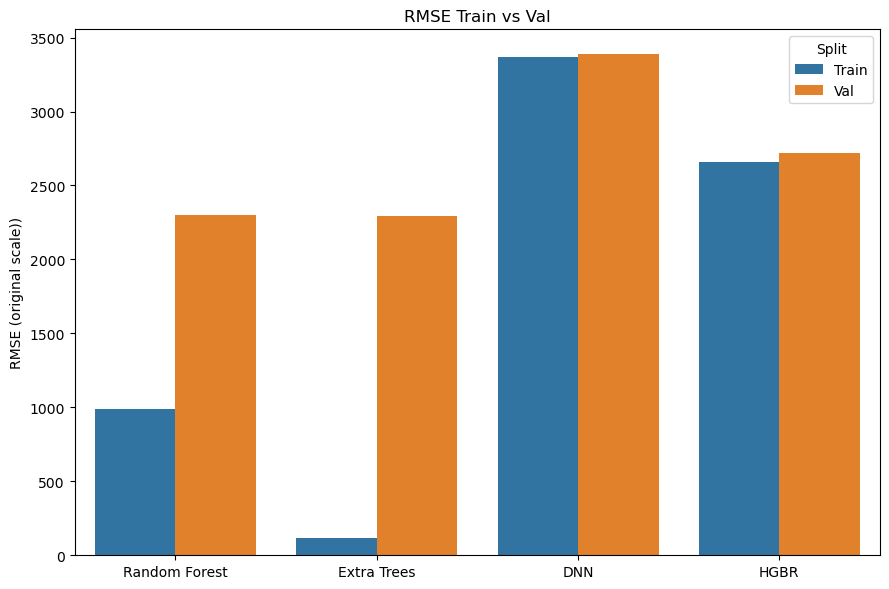

In [ ]:
# Creating a representative bar plot for RMSE values
rmse_plot = pd.DataFrame({
    "Model": [
        "Random Forest", "Random Forest",
        "Extra Trees",   "Extra Trees",
        "DNN",           "DNN",
        "HGBR",          "HGBR"
    ],
    "Split": [
        "Train", "Val",
        "Train", "Val",
        "Train", "Val",
        "Train", "Val"
    ],
    "RMSE": [
        results.loc["RF RMSE (Train)",   "Value"],
        results.loc["RF RMSE (Val)",     "Value"],
        results.loc["ET RMSE (Train)",   "Value"],
        results.loc["ET RMSE (Val)",     "Value"],
        results.loc["DNN RMSE (Train)",  "Value"],
        results.loc["DNN RMSE (Val)",    "Value"],
        results.loc["HGBR RMSE (Train)", "Value"],
        results.loc["HGBR RMSE (Val)",   "Value"],
    ]
})

plt.figure(figsize=(9, 6))
sns.barplot(
    data=rmse_plot,
    x="Model",
    y="RMSE",
    hue="Split"
)
plt.title("RMSE Train vs Val")
plt.ylabel("RMSE (original scale))")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Random Search

### Extra trees

In [ ]:
# Initial Parameters

param_dist_et = {
    'n_estimators': [300, 500, 800],
    'min_samples_leaf': [2, 4, 8, 12, 16],
    'min_samples_split': [5, 10, 20],
    'max_depth': [20, 30, 40, None],
    'max_features': ['sqrt', 0.6, 0.8]
}

N_ITER = 60
results = []

best_rmse_val = float("inf")
best_et_model = None
best_params = None


# Random Search

for i in range(N_ITER):

    params = {
        'n_estimators': random.choice(param_dist_et['n_estimators']),
        'min_samples_leaf': random.choice(param_dist_et['min_samples_leaf']),
        'min_samples_split': random.choice(param_dist_et['min_samples_split']),
        'max_depth': random.choice(param_dist_et['max_depth']),
        'max_features': random.choice(param_dist_et['max_features']),
    }

    model = ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    # train with log
    model.fit(X_train, y_train_log)

    # predict with log
    pred_train_log = model.predict(X_train)
    pred_val_log   = model.predict(X_val)

    # back to original scale
    pred_train = np.expm1(pred_train_log)
    pred_val   = np.expm1(pred_val_log)

    # creating the metrics in the original scale
    rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
    rmse_val   = mean_squared_error(y_val, pred_val) ** 0.5
    gap = rmse_val - rmse_train

    results.append({
        **params,
        "rmse_train": rmse_train,
        "rmse_val": rmse_val,
    })

    print(f"[{i+1}/{N_ITER}] rmse_train={rmse_train:.2f} | rmse_val={rmse_val:.2f}")

    # keeps the model with lowest RMSE on validation set
    if rmse_val < best_rmse_val:
        best_rmse_val = rmse_val
        best_et_model = model
        best_params = params

# Final Results
results_et_df = (
    pd.DataFrame(results)
      .sort_values("rmse_val")
      .reset_index(drop=True)
)

print("\nBest parameters ExtraTrees:")
print(best_params)
print(f"Best RMSE_val: {best_rmse_val:.2f}")

[1/60] rmse_train=1869.47 | rmse_val=2462.61
[2/60] rmse_train=2793.26 | rmse_val=2930.58
[3/60] rmse_train=3583.73 | rmse_val=3625.74
[4/60] rmse_train=2794.87 | rmse_val=2932.71
[5/60] rmse_train=3116.19 | rmse_val=3213.40
[6/60] rmse_train=2050.28 | rmse_val=2477.53
[7/60] rmse_train=2793.26 | rmse_val=2930.58
[8/60] rmse_train=2991.65 | rmse_val=3086.62
[9/60] rmse_train=3112.77 | rmse_val=3214.19
[10/60] rmse_train=3115.04 | rmse_val=3212.35
[11/60] rmse_train=2538.18 | rmse_val=2756.98
[12/60] rmse_train=3121.50 | rmse_val=3194.87
[13/60] rmse_train=2108.72 | rmse_val=2499.50
[14/60] rmse_train=2304.00 | rmse_val=2633.59
[15/60] rmse_train=2161.76 | rmse_val=2549.85
[16/60] rmse_train=3379.96 | rmse_val=3438.41
[17/60] rmse_train=2533.30 | rmse_val=2751.51
[18/60] rmse_train=3568.06 | rmse_val=3606.54
[19/60] rmse_train=2578.62 | rmse_val=2813.32
[20/60] rmse_train=2710.19 | rmse_val=2880.23
[21/60] rmse_train=3583.73 | rmse_val=3625.74
[22/60] rmse_train=3380.27 | rmse_val=3436.

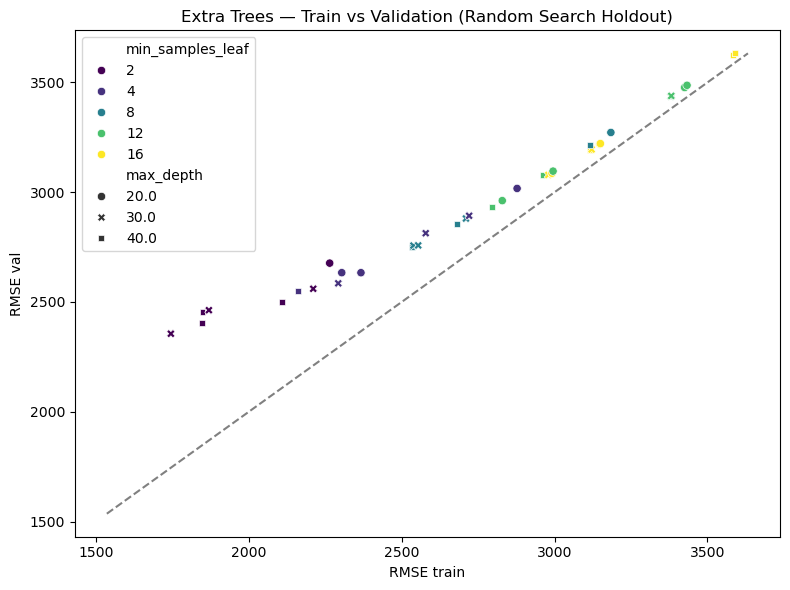

n_estimators                 800
min_samples_leaf               4
min_samples_split             10
max_depth                    NaN
max_features                 0.8
rmse_train           2050.278089
rmse_val             2477.531995
gap                   427.253906
Name: 9, dtype: object

In [166]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=results_et_df,
    x="rmse_train",
    y="rmse_val",
    hue="min_samples_leaf",
    style="max_depth",
    palette="viridis"
)
plt.plot(
    [results_et_df["rmse_train"].min(), results_et_df["rmse_val"].max()],
    [results_et_df["rmse_train"].min(), results_et_df["rmse_val"].max()],
    "--", color="grey"
)
plt.xlabel("RMSE train")
plt.ylabel("RMSE val")
plt.title("Extra Trees — Train vs Validation (Random Search Holdout)")
plt.tight_layout()
plt.show()

results_et_df["gap"] = results_et_df["rmse_val"] - results_et_df["rmse_train"]

top = results_et_df.nsmallest(10, "rmse_val")
best_stable = top.loc[top["gap"].idxmin()]
best_stable

### Random Forest

In [ ]:
# Initial Parameters
param_dist_rf = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [8, 12, 15],
    "min_samples_leaf": [4, 8, 12, 16],
    "max_features": ["sqrt", 0.5, 0.7],
}

N_ITER = 60
results = []

best_rmse_val = float("inf")
best_rf_model = None
best_params = None

# Random Search

for i in range(N_ITER):
    params = {
        "n_estimators": random.choice(param_dist_rf["n_estimators"]),
        "max_depth": random.choice(param_dist_rf["max_depth"]),
        "min_samples_leaf": random.choice(param_dist_rf["min_samples_leaf"]),
        "max_features": random.choice(param_dist_rf["max_features"]),
    }

    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    # train with log
    model.fit(X_train, y_train_log)

    # pedict with log
    pred_train_log = model.predict(X_train)
    pred_val_log   = model.predict(X_val)

    # back to original scale
    pred_train = np.expm1(pred_train_log)
    pred_val   = np.expm1(pred_val_log)

    # creating the metrics in the original scale
    rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
    rmse_val   = mean_squared_error(y_val, pred_val) ** 0.5
    gap = rmse_val - rmse_train

    results.append({
        **params,
        "rmse_train": rmse_train,
        "rmse_val": rmse_val,
    })

    print(f"[{i+1}/{N_ITER}] rmse_train={rmse_train:.4f} | rmse_val={rmse_val:.4f}")

    # keeps the model with lowest RMSE on validation set
    if rmse_val < best_rmse_val:
        best_rmse_val = rmse_val
        best_rf_model = model
        best_params = params

results_rf_df = pd.DataFrame(results).sort_values("rmse_val").reset_index(drop=True)

print("\nBest parameters:")
print(best_params)
print(f"Best RMSE_val: {best_rmse_val:.4f}")


[1/60] rmse_train=2874.3028 | rmse_val=2993.2018
[2/60] rmse_train=3527.5855 | rmse_val=3560.1188
[3/60] rmse_train=3500.4481 | rmse_val=3520.4356
[4/60] rmse_train=2227.3893 | rmse_val=2562.7822
[5/60] rmse_train=2706.5901 | rmse_val=2851.2103
[6/60] rmse_train=2860.0155 | rmse_val=2976.7905
[7/60] rmse_train=3527.5855 | rmse_val=3560.1188
[8/60] rmse_train=2706.5901 | rmse_val=2851.2103
[9/60] rmse_train=3437.4054 | rmse_val=3475.4710
[10/60] rmse_train=2467.4699 | rmse_val=2715.2613
[11/60] rmse_train=3344.4036 | rmse_val=3387.6837
[12/60] rmse_train=2467.4699 | rmse_val=2715.2613
[13/60] rmse_train=2703.0239 | rmse_val=2851.4655
[14/60] rmse_train=2140.9684 | rmse_val=2504.1721
[15/60] rmse_train=3476.1539 | rmse_val=3507.1777
[16/60] rmse_train=2570.2833 | rmse_val=2759.4374
[17/60] rmse_train=3326.5991 | rmse_val=3374.9327
[18/60] rmse_train=2905.2291 | rmse_val=3008.3523
[19/60] rmse_train=2905.1546 | rmse_val=3010.7820
[20/60] rmse_train=3391.0941 | rmse_val=3424.1617
[21/60] r

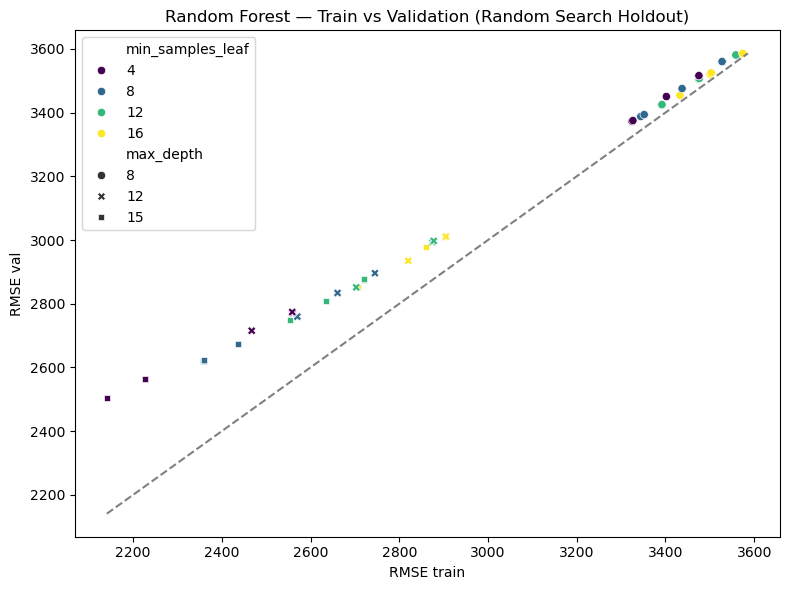

n_estimators                500
max_depth                    15
min_samples_leaf              8
max_features                0.5
rmse_train          2435.656079
rmse_val            2672.722969
gap                  237.066891
Name: 8, dtype: object

In [159]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=results_rf_df,
    x="rmse_train",
    y="rmse_val",
    hue="min_samples_leaf",
    style="max_depth",
    palette="viridis"
)
plt.plot(
    [results_rf_df["rmse_train"].min(), results_rf_df["rmse_val"].max()],
    [results_rf_df["rmse_train"].min(), results_rf_df["rmse_val"].max()],
    "--", color="grey"
)
plt.xlabel("RMSE train")
plt.ylabel("RMSE val")
plt.title("Random Forest — Train vs Validation (Random Search Holdout)")
plt.tight_layout()
plt.show()

results_rf_df["gap"] = results_rf_df["rmse_val"] - results_rf_df["rmse_train"]

top = results_rf_df.nsmallest(10, "rmse_val")
best_stable = top.loc[top["gap"].idxmin()]
best_stable

### HGBR

In [ ]:
# Initial Parameters
param_dist_hgbr = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.5],
    "max_iter": [100, 200, 500, 1000],
    "max_leaf_nodes": [15, 31, 63, 127],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0],
    "max_depth": [None, 5, 10, 20],
    "early_stopping": [True, False],
}

N_ITER = 60
results = []

best_rmse_val = float("inf")
best_hgb_model = None
best_params = None

# Random Search
for i in range(N_ITER):

    params = {
        "learning_rate": random.choice(param_dist_hgbr["learning_rate"]),
        "max_iter": random.choice(param_dist_hgbr["max_iter"]),
        "max_leaf_nodes": random.choice(param_dist_hgbr["max_leaf_nodes"]),
        "min_samples_leaf": random.choice(param_dist_hgbr["min_samples_leaf"]),
        "l2_regularization": random.choice(param_dist_hgbr["l2_regularization"]),
        "max_depth": random.choice(param_dist_hgbr["max_depth"]),
        "early_stopping": random.choice(param_dist_hgbr["early_stopping"]),
    }

    model = HistGradientBoostingRegressor(
        random_state=42,
        **params
    )

    # train with log
    model.fit(X_train, y_train_log)

    # predict with log
    pred_train_log = model.predict(X_train)
    pred_val_log   = model.predict(X_val)

    # back to original scale
    pred_train = np.expm1(pred_train_log)
    pred_val   = np.expm1(pred_val_log)

    # creating the metrics in the original scale
    rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
    rmse_val   = mean_squared_error(y_val, pred_val) ** 0.5
    gap = rmse_val - rmse_train

    results.append({
        **params,
        "rmse_train": rmse_train,
        "rmse_val": rmse_val
    })

    print(f"[{i+1}/{N_ITER}] rmse_train={rmse_train:.4f} | rmse_val={rmse_val:.4f}")

    # keeps the model with lowest RMSE on validation set
    if rmse_val < best_rmse_val:
        best_rmse_val = rmse_val
        best_hgbr_model = model
        best_params = params

    results_hgbr_df = pd.DataFrame(results).sort_values("rmse_val").reset_index(drop=True)

    print("\nBest parameters:")
    print(best_params)
    print(f"Best RMSE_val: {best_rmse_val:.4f}")

[1/60] rmse_train=2375.9385 | rmse_val=2495.1195

Melhores parâmetros encontrados:
{'learning_rate': 0.5, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'l2_regularization': 0.0, 'max_depth': 5, 'early_stopping': False}
Melhor RMSE_val: 2495.1195
[2/60] rmse_train=1955.4620 | rmse_val=2335.3706

Melhores parâmetros encontrados:
{'learning_rate': 0.5, 'max_iter': 500, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0, 'max_depth': 10, 'early_stopping': True}
Melhor RMSE_val: 2335.3706
[3/60] rmse_train=6140.4632 | rmse_val=6147.9794

Melhores parâmetros encontrados:
{'learning_rate': 0.5, 'max_iter': 500, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0, 'max_depth': 10, 'early_stopping': True}
Melhor RMSE_val: 2335.3706
[4/60] rmse_train=2766.9978 | rmse_val=2807.9122

Melhores parâmetros encontrados:
{'learning_rate': 0.5, 'max_iter': 500, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0, 'max_depth': 10,

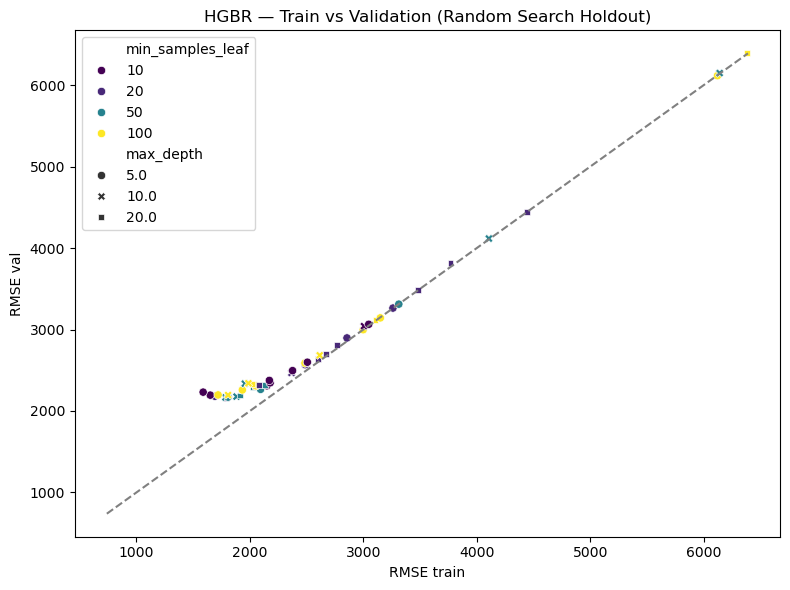

In [161]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=results_hgbr_df,
    x="rmse_train",
    y="rmse_val",
    hue="min_samples_leaf",
    style="max_depth",
    palette="viridis"
)
plt.plot(
    [results_hgbr_df["rmse_train"].min(), results_hgbr_df["rmse_val"].max()],
    [results_hgbr_df["rmse_train"].min(), results_hgbr_df["rmse_val"].max()],
    "--", color="grey"
)
plt.xlabel("RMSE train")
plt.ylabel("RMSE val")
plt.title("HGBR — Train vs Validation (Random Search Holdout)")
plt.tight_layout()
plt.show()

### DNN

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Initial Parameters

param_dist_dnn = {
    "n_hidden":      [1, 2, 3],
    "units":         [32, 64, 128],
    "dropout_rate":  [0.0, 0.2, 0.4],
    "learning_rate": [1e-2, 5e-3, 1e-3],
    "batch_size":    [32, 64, 128],
    "epochs":        [40, 60]
}

def random_search_dnn(param_grid,
                      X_train_s, y_train_log,
                      X_val_s,   y_val_log,
                      n_iter=60):

    results = []
    best_rmse_val = float("inf")
    best_model = None
    best_params = None

    keys = list(param_grid.keys())

    # original scale
    y_train_true = np.expm1(y_train_log)
    y_val_true   = np.expm1(y_val_log)

    for i in range(n_iter):
        params = {k: random.choice(param_grid[k]) for k in keys}

        model = build_dnn(
            input_dim=X_train_s.shape[1],
            n_hidden=params["n_hidden"],
            units=params["units"],
            dropout_rate=params["dropout_rate"],
            learning_rate=params["learning_rate"],
        )

        # early stopping
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=0
        )

        # train with log
        model.fit(
            X_train_s, y_train_log,
            validation_data=(X_val_s, y_val_log),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            callbacks=[early_stop],
            verbose=0
        )

        # predict with log
        pred_train_log = model.predict(X_train_s, verbose=0).flatten()
        pred_val_log   = model.predict(X_val_s,   verbose=0).flatten()

        # back to original scale
        pred_train = np.expm1(pred_train_log)
        pred_val   = np.expm1(pred_val_log)

        # creating the metrics in the original scale
        rmse_train = mean_squared_error(y_train_true, pred_train) ** 0.5
        rmse_val   = mean_squared_error(y_val_true,   pred_val) ** 0.5

        results.append({
            **params,
            "rmse_train": rmse_train,
            "rmse_val":   rmse_val,
        })

        print(f"[{i+1}/{n_iter}] rmse_train={rmse_train:.2f} | rmse_val={rmse_val:.2f}")

        # keeps the model with lowest RMSE on validation set
        if rmse_val < best_rmse_val:
            best_rmse_val = rmse_val
            best_model = model
            best_params = params

    results_dnn_df = (
        pd.DataFrame(results)
        .sort_values("rmse_val")
        .reset_index(drop=True)
    )
    return results_dnn_df, best_model, best_params

results_dnn_df, best_dnn_model, best_dnn_params = random_search_dnn(
    param_dist_dnn,
    X_train_scaled, y_train_log,
    X_val_scaled,   y_val_log,
    n_iter=20  
)

print("\nBest parameters:")
print(best_dnn_params)
print(f"Best RMSE_val DNN: {results_dnn_df['rmse_val'].iloc[0]:.2f}")

c:\Users\Catarina\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[1/20] rmse_train=3496.69 | rmse_val=3488.60


c:\Users\Catarina\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[2/20] rmse_train=3751.51 | rmse_val=3729.78


c:\Users\Catarina\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

[18/20] rmse_train=3632.40 | rmse_val=3608.23


c:\Users\Catarina\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[19/20] rmse_train=3303.63 | rmse_val=3298.57


c:\Users\Catarina\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[20/20] rmse_train=3464.64 | rmse_val=3459.48

Melhores parâmetros DNN:
{'n_hidden': 1, 'units': 128, 'dropout_rate': 0.0, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 60}
Melhor RMSE_val DNN: 3274.25


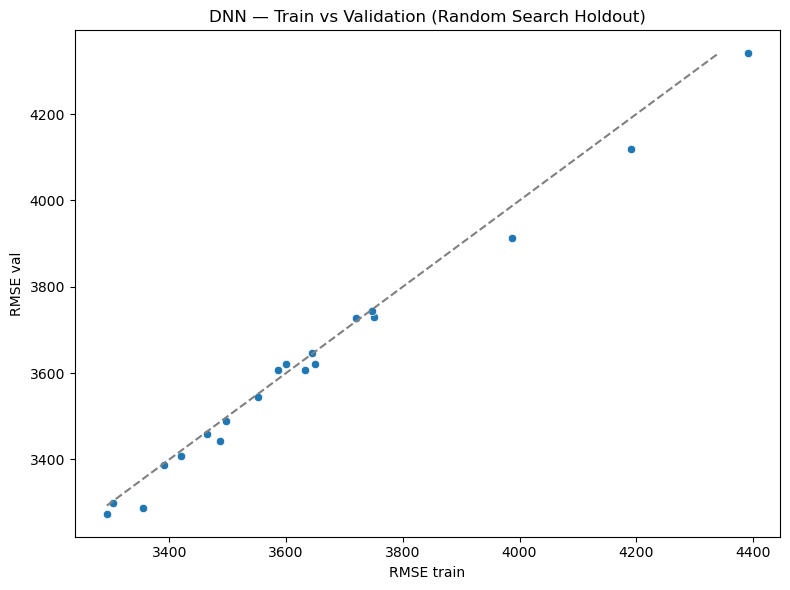

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=results_dnn_df,
    x="rmse_train",
    y="rmse_val"
)
plt.plot(
    [results_dnn_df["rmse_train"].min(), results_dnn_df["rmse_val"].max()],
    [results_dnn_df["rmse_train"].min(), results_dnn_df["rmse_val"].max()],
    "--", color="grey"
)
plt.xlabel("RMSE train")
plt.ylabel("RMSE val")
plt.title("DNN — Train vs Validation (Random Search Holdout)")
plt.tight_layout()
plt.show()

## Tuned Benchmarking

In [132]:
def final_benchmark_log(
    X_train, y_train_log,
    X_val,   y_val_log,
    rf_params,
    et_params,
    mlp_params,     
    hgbr_params,
    ridge_params
):
    results = {}
    fitted_models = {}

    # ======================
    # Random Forest
    # ======================
    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )
    rf.fit(X_train, y_train_log)
    fitted_models["rf"] = rf

    pred_train = np.expm1(rf.predict(X_train))
    pred_val   = np.expm1(rf.predict(X_val))

    results["RF_RMSE_train"] = mean_squared_error(y_train, pred_train) ** 0.5
    results["RF_MAE_train"]  = mean_absolute_error(y_train, pred_train)
    results["RF_RMSE_val"]   = mean_squared_error(y_val, pred_val) ** 0.5
    results["RF_MAE_val"]    = mean_absolute_error(y_val, pred_val)

    # ======================
    # Extra Trees
    # ======================
    et = ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1,
        **et_params
    )
    et.fit(X_train, y_train_log)
    fitted_models["et"] = et

    pred_train = np.expm1(et.predict(X_train))
    pred_val   = np.expm1(et.predict(X_val))

    results["ET_RMSE_train"] = mean_squared_error(y_train, pred_train) ** 0.5
    results["ET_MAE_train"]  = mean_absolute_error(y_train, pred_train)
    results["ET_RMSE_val"]   = mean_squared_error(y_val, pred_val) ** 0.5
    results["ET_MAE_val"]    = mean_absolute_error(y_val, pred_val)

    # ======================
    # MLP (sklearn replacement for DNN)
    # ======================
    mlp = MLPRegressor(
        hidden_layer_sizes=mlp_params["hidden_layer_sizes"],
        activation="relu",
        solver=mlp_params["solver"],
        learning_rate_init=mlp_params["learning_rate"],
        max_iter=mlp_params["max_iter"],
        alpha=mlp_params["alpha"],
        random_state=42,
        verbose=False
    )
    mlp.fit(X_train, y_train_log)
    fitted_models["mlp"] = mlp

    pred_train = np.expm1(mlp.predict(X_train))
    pred_val   = np.expm1(mlp.predict(X_val))

    results["MLP_RMSE_train"] = mean_squared_error(y_train, pred_train) ** 0.5
    results["MLP_MAE_train"]  = mean_absolute_error(y_train, pred_train)
    results["MLP_RMSE_val"]   = mean_squared_error(y_val, pred_val) ** 0.5
    results["MLP_MAE_val"]    = mean_absolute_error(y_val, pred_val)

    # ======================
    # HGBR
    # ======================
    hgbr = HistGradientBoostingRegressor(
        random_state=42,
        **hgbr_params
    )
    hgbr.fit(X_train, y_train_log)
    fitted_models["hgbr"] = hgbr

    pred_train = np.expm1(hgbr.predict(X_train))
    pred_val   = np.expm1(hgbr.predict(X_val))

    results["HGBR_RMSE_train"] = mean_squared_error(y_train, pred_train) ** 0.5
    results["HGBR_MAE_train"]  = mean_absolute_error(y_train, pred_train)
    results["HGBR_RMSE_val"]   = mean_squared_error(y_val, pred_val) ** 0.5
    results["HGBR_MAE_val"]    = mean_absolute_error(y_val, pred_val)

    # ======================
    # Ridge Regressor
    # =====================
    ridge = Ridge(
        **ridge_params,
        random_state=42
    )
    ridge.fit(X_train, y_train_log)
    fitted_models["ridge"] = ridge

    pred_train = np.expm1(ridge.predict(X_train))
    pred_val   = np.expm1(ridge.predict(X_val))

    results["Ridge_RMSE_train"] = mean_squared_error(y_train, pred_train) ** 0.5
    results["Ridge_MAE_train"]  = mean_absolute_error(y_train, pred_train)
    results["Ridge_RMSE_val"]   = mean_squared_error(y_val, pred_val) ** 0.5
    results["Ridge_MAE_val"]    = mean_absolute_error(y_val, pred_val)

    # ======================
    # Linear Regression
    # ======================
    lr = LinearRegression()
    lr.fit(X_train, y_train_log)
    fitted_models["linear"] = lr

    pred_train = np.expm1(lr.predict(X_train))
    pred_val   = np.expm1(lr.predict(X_val))

    results["LR_RMSE_train"] = mean_squared_error(y_train, pred_train) ** 0.5
    results["LR_MAE_train"]  = mean_absolute_error(y_train, pred_train)
    results["LR_RMSE_val"]   = mean_squared_error(y_val, pred_val) ** 0.5
    results["LR_MAE_val"]    = mean_absolute_error(y_val, pred_val)

    # ======================
    # Results table
    # ======================
    df = pd.DataFrame([
        ["RandomForest", results["RF_RMSE_train"], results["RF_MAE_train"],
         results["RF_RMSE_val"], results["RF_MAE_val"]],
        ["ExtraTrees", results["ET_RMSE_train"], results["ET_MAE_train"],
         results["ET_RMSE_val"], results["ET_MAE_val"]],
        ["MLP", results["MLP_RMSE_train"], results["MLP_MAE_train"],
         results["MLP_RMSE_val"], results["MLP_MAE_val"]],
        ["HGBR", results["HGBR_RMSE_train"], results["HGBR_MAE_train"],
         results["HGBR_RMSE_val"], results["HGBR_MAE_val"]],
        ["Ridge", results["Ridge_RMSE_train"], results["Ridge_MAE_train"],
         results["Ridge_RMSE_val"], results["Ridge_MAE_val"]],
        ["Linear", results["LR_RMSE_train"], results["LR_MAE_train"],
         results["LR_RMSE_val"], results["LR_MAE_val"]],
    ], columns=["Model", "RMSE_train", "MAE_train", "RMSE_val", "MAE_val"])

    return df.set_index("Model"), fitted_models

In [133]:
# Best hyperparameters from random search

rf_best_params = {
    "n_estimators": 500,
    "max_depth": 15,
    "min_samples_leaf": 8,
    "max_features": 0.5,
}

et_best_params = {
    "n_estimators": 300,
    "min_samples_leaf": 2,
    "min_samples_split": 20,
    "max_depth": None,
    "max_features": 0.8,
} 

mlp_best_params = {
    "hidden_layer_sizes": (9,9,9),
    "learning_rate": 0.005,
    "max_iter": 300,
    "alpha": 0.0001,
    "solver": "adam"
}


hgbr_params = {
    'learning_rate': 0.05, 
    'max_iter': 1000, 
    'max_leaf_nodes': 63, 
    'min_samples_leaf': 10, 
    'l2_regularization': 1.0, 
    'max_depth': None, 
    'early_stopping': False
}

ridge_params = {
    "alpha": 10,   
    "solver": "auto" 
}

benchmark_log_df, final_models = final_benchmark_log(
    X_train, y_train_log,
    X_val,   y_val_log,
    rf_params=rf_best_params,
    et_params=et_best_params,
    mlp_params=mlp_best_params,
    hgbr_params=hgbr_params,
    ridge_params=ridge_params
)

display(benchmark_log_df)

c:\Users\Catarina\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não conseguiu localizar o ficheiro especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Catarina\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Catarina\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Catarina\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~

,RMSE_train,MAE_train,RMSE_val,MAE_val
Model,,,,
RandomForest,2456.623273,1338.420115,2684.807814,1514.854834
ExtraTrees,2132.397428,1172.589627,2511.692374,1411.442693
MLP,4459.504779,2894.285830,4399.862024,2897.294542
HGBR,1743.476774,1063.821874,2163.796221,1295.826369
Ridge,5160.433901,3264.138402,5122.393231,3272.963709
Linear,5156.074508,3258.375549,5116.079978,3268.429160


After the individual optimization of each model, we created a benchmarking in order to analyse the performance of each model with the chosen hyperparamethers. Based on these results, we decided to test a stacking experimental model, so that we could evaluate if the combination of the models could improve their performance, comparing with the original result.

Com base nos resultados do benchmarking final, apenas os modelos com desempenho competitivo no conjunto de validação foram considerados para o stacking. O modelo DNN foi excluído por apresentar um erro significativamente superior, o que poderia introduzir ruído no modelo ensemble. O stacking foi assim construído com os modelos HGBR e ExtraTrees, que apresentaram bom desempenho individual e diferentes mecanismos de aprendizagem

## Stacking

In [134]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

# Final models
hgbr = final_models["hgbr"]
et   = final_models["et"]

# Base predictions
hgbr_val_log = hgbr.predict(X_val)
et_val_log   = et.predict(X_val)

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

X_meta_val = np.column_stack([hgbr_val_log, et_val_log])
y_meta_val = y_val_log

# Meta-model
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(X_meta_val, y_meta_val)

# Real scale evaluation
y_val_true = np.expm1(y_val_log)

hgbr_val_pred  = np.expm1(hgbr_val_log)
et_val_pred    = np.expm1(et_val_log)
stack_val_pred = np.expm1(meta_model.predict(X_meta_val))

stack_results = pd.DataFrame({
    "Model": ["HGBR", "ExtraTrees", "STACK (HGBR + ET)"],
    "RMSE_val": [
        rmse(y_val_true, hgbr_val_pred),
        rmse(y_val_true, et_val_pred),
        rmse(y_val_true, stack_val_pred),
    ],
    "MAE_val": [
        mean_absolute_error(y_val_true, hgbr_val_pred),
        mean_absolute_error(y_val_true, et_val_pred),
        mean_absolute_error(y_val_true, stack_val_pred),
    ]
}).set_index("Model")

display(stack_results)

# saving the stacking meta-model
final_models["stack_meta_hgbr_et"] = meta_model

,RMSE_val,MAE_val
Model,,
HGBR,2163.796221,1295.826369
ExtraTrees,2511.692374,1411.442693
STACK (HGBR + ET),2165.398993,1290.291879


A stacking ensemble was built using the two best-performing individual models (HistGradientBoostingRegressor and ExtraTreesRegressor).
The base models were trained on the logarithm of the target variable.
Their validation predictions were then used as inputs to a Ridge regression meta-model (α = 1.0), also trained in log-space.
Final predictions were transformed back to the original scale for evaluation using RMSE and MAE

The stacking ensemble achieved a validation performance comparable to the best individual model (HGBR), confirming its robustness. Although no significant improvement was observed, the stacking model did not degrade performance and slightly improved MAE, suggesting a stabilizing effect rather than a performance boost

## final benchmarking

After hyperparameter tuning, a final benchmarking was performed.
The stacking model was then evaluated using the same train/validation split and appended to the benchmarking results for direct comparison

In [136]:
final_table = (
    pd.concat(
        [benchmark_log_df, stack_results.iloc[[-1]]],
        axis=0
    )
    .sort_values("RMSE_val")
)

display(final_table)

,RMSE_train,MAE_train,RMSE_val,MAE_val
Model,,,,
HGBR,1743.476774,1063.821874,2163.796221,1295.826369
STACK (HGBR + ET),NaN,NaN,2165.398993,1290.291879
ExtraTrees,2132.397428,1172.589627,2511.692374,1411.442693
RandomForest,2456.623273,1338.420115,2684.807814,1514.854834
MLP,4459.504779,2894.285830,4399.862024,2897.294542
Linear,5156.074508,3258.375549,5116.079978,3268.429160
Ridge,5160.433901,3264.138402,5122.393231,3272.963709


# submission

In [ ]:
hgbr_final = final_models["hgbr"]
X_test = test_data.copy()

# predict with log
test_pred_log = hgbr_final.predict(X_test)

# back to original scale
test_pred_price = np.expm1(test_pred_log)

submission = pd.DataFrame({
    "carID": X_test.index,
    "price": test_pred_price
})

submission.to_csv("submission_hgbr.csv", index=False)

Ficheiro criado: submission_hgbr.csv
